# Giant donut profiles and wavefront fits, intra against extra focal (v2)

**Author:** Aaron Roodman
**Date Created:** 2026-10-05

Radial and azimuthal flux profiles of the 8 mm giant donuts on both sides of
focus, on the near-on-axis sensor R22_S10, testing whether the ring of excess flux
Josh sees in extra-focal donuts is a pupil-model (mask boundary) effect or an
optical path difference (OPD) effect such as a turned-down edge on the inside of
M1.

Then the same two donuts fitted with ts_wep's blitz forward model in four
configurations -- the v3.14 and v1000 pupil models, each with spider shadows off
and on -- with each fit's model image profiled the same way as the data and
overlaid on it.

Part of item 7 of `notes/todos/todo-ideas.md`. Settled inputs and the state of the
investigation are in `notes/status/item7_giant_donuts_handoff.md`; the superseded
geometry work is `wfs/docs/giant_donuts_pupil_findings.md`.

## What this notebook is for

The two hypotheses make different predictions, which is what makes the radial
profile a discriminator rather than a description:

| | mask boundary error | OPD error (turned-down M1 inner edge) |
|---|---|---|
| where | at the pupil edge | smooth, weighted to the pupil edge |
| flux | conserved on each side of the edge | redistributed **across** the edge |
| intra against extra | same sign | **reverses sign** |
| pupil model | radius differs v3.14 against v1000 | unchanged by the pupil model |

So the diagnostic is the **intra minus extra difference** of the normalised
profile, not either profile alone.

## Geometry this rests on

Traced on-axis through the full system with batoid, the surviving pupil annulus is

| model | inner edge | outer edge |
|---|---|---|
| v3.14 | 2.5580 m | 4.1796 m (M1 rim) |
| v1000 | 2.5840 m | 4.1650 m (M1 baffles) |

The inner edge is M1's inner radius in both, and it moves **outward by 26.0 mm**
from v3.14 to v1000 — the same place a turned-down M1 inner edge would act. The
v1000 outer edge is set by the new M1 baffles, 15 mm inside M1's unchanged rim.


## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Data Access](#data)
5. [Binning](#binning)
6. [Analysis: radial profiles](#analysis)
7. [Results & Plots](#results)
8. [Azimuthal profiles](#azimuthal)
9. [Wavefront fits: two pupil models, spiders off and on](#fits)
10. [Fitted Zernikes and blur](#zktable)
11. [Residual images](#residuals)
12. [Interpretation](#interpretation)

<a id='params'></a>
## Parameters

In [1]:
# ============================================================
# Parameters
# ============================================================
butler_repo = "/repo/main"
raw_collection = "LSSTCam/raw/all"
instrument = "LSSTCam"

# day_obs 20251023, BLOCK-T626, r band, 60 s. The defocus is a symmetric
# 4 + 4 mm split: +/-4000 um on the M2 hexapod (Trim dof0) and +/-4000 um on the
# camera hexapod (Trim dof5), against the in-focus seq_num 336. Established
# label-independently from the Trim -- see the handoff.
EXPOSURES = {
    "extra": 2025102300337,   # extra_8mm, Bryce's pair
    "intra": 2025102300340,   # intra_8mm, Bryce's pair
}

# Near-on-axis science sensor (field radius 0.235 deg), per item 7 Q6 and Aaron's
# note that Bryce found a good isolated donut here. R22_S11 is exactly on-axis if
# a second sensor is wanted; R30_S21 at 1.695 deg is what the archived notebook used.
detector_name = "R22_S10"

# Stamp half-size, in pixels. Measured on this data the giant donut is about
# 695 pixels across, i.e. a radius of about 347 pixels, so the stamp must be
# comfortably larger than that or the profile is cut off before the outer edge.
stamp_half_pix = 430

# Radial and azimuthal binning. Both come from rp, where the convergence scans
# that set them are documented; the Binning section below reproduces those scans.
# Radial is 1.5 pixel per bin, which resolves the 9.0 pixel edge roll-off.
# Azimuthal is 0.25 deg per bin, which puts about 3.4 bins across a 0.86 deg
# spider vane so the vane profile is resolved, not merely detected.
radial_bin_pix = 1.5
n_radial_bins = int(round(stamp_half_pix / radial_bin_pix))

# The annulus the azimuthal profile averages over, as a fraction of the outer
# edge. It excludes both edges so the profile is not dominated by roll-off or by
# a small centring error.
azimuthal_bin_deg = 0.25
n_azimuthal_bins = int(round(360.0 / azimuthal_bin_deg))
azimuthal_annulus = (0.65, 0.95)

# Pupil radius, in meters, used only to state the angular scale the
# azimuthal binning has to resolve.
instrument_radius_m = 4.18

# Fit configurations: the 2x2 of pupil model against spider modelling.
FIT_CONFIGS = [
    ("v3.14", False), ("v3.14", True),
    ("v1000", False), ("v1000", True),
]

# Blur FWHM upper bound, in arcsec, for the free-blur fits. blitz hardcodes 5.0.
# 1.5 was tried first and the intra-focal fit pinned on it in all four pupil
# configurations, so the bound is relaxed to 3.0 to check whether that pinning
# was biasing the Zernikes.
fwhm_max_arcsec = 3.0

# Fixed blur, in arcsec, for the second set of fits. The DIMM read 0.65 to
# 0.80 arcsec on these visits and nearby in-focus acquisition images had about
# 0.9 arcsec of blur, so 0.7 arcsec is an independent measurement of the seeing
# rather than something the donut fit has to discover. Holding it there tests
# whether the spider depth and the inner and outer rings are modelled correctly
# once the blur can no longer absorb their mismatch.
fwhm_fixed_arcsec = 0.7

# The two blur treatments, run as separate passes over FIT_CONFIGS. 'free' is
# the 0.1 to fwhm_max_arcsec bound; 'fixed' pins the blur at fwhm_fixed_arcsec.
BLUR_MODES = ("free", "fixed")

# least_squares tolerance. blitz defaults to 1e-3, which stops a giant-donut
# fit after about 5 function evaluations.
fit_tol = 1e-8

# ts_wep checkout carrying the blitz prototype. The shared checkout is on
# `develop`, which has no blitz subpackage.
fit_blitz_python = "/sdf/home/r/roodman/u/LSST/packages/ts_wep_blitz/python"

# Generated v1000 maskParams, from gen_mask_params.py.
mask_params_v1000 = "../../output/giant_donuts/maskParams_v1000.yaml"

output_dir = "../../output/giant_donuts"


<a id='setup'></a>
## Setup & Imports

In [2]:
import logging
import os
import sys
from pathlib import Path

# Topic directory is the nearest parent holding a code/ dir; the repo root is its
# parent. Both must go on sys.path before any repo import, so `common` and this
# study's modules are importable.
_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))                      # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code' / 'giant_donuts'))   # this study

import numpy as np
import matplotlib.pyplot as plt

import lsst.daf.butler as dafButler
from lsst.obs.lsst import LsstCam

from common.utils import setup_plotting

import radial_profile as rp
import donut_images as di
import fit_giant_donut as fg

# IsrTask logs a dozen INFO lines per exposure, which buries the printed
# results; the warning about the r_57 zero point is expected and harmless.
logging.getLogger('lsst.isr').setLevel(logging.WARNING)

setup_plotting()
camera = LsstCam.getCamera()
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Fail loudly if the notebook's bin sizes drift from the module's documented
# choices, rather than silently producing differently-binned numbers.
assert radial_bin_pix == rp.RADIAL_BIN_PIX, (radial_bin_pix, rp.RADIAL_BIN_PIX)
assert azimuthal_bin_deg == rp.AZIMUTHAL_BIN_DEG, (
    azimuthal_bin_deg, rp.AZIMUTHAL_BIN_DEG)
print(f"radial {radial_bin_pix} pixel per bin -> {n_radial_bins} bins")
print(f"azimuthal {azimuthal_bin_deg} deg per bin -> {n_azimuthal_bins} bins")


radial 1.5 pixel per bin -> 287 bins
azimuthal 0.25 deg per bin -> 1440 bins


<a id='functions'></a>
## Helper Functions

Minimal instrument signature removal (ISR) and sky handling, following the
archived `wfs_giant_donut_fit.ipynb`: the giant-donut exposures carry no donut
tables and no pipeline fits, so the stamps are cut from the raw here.

Note the item's reference to `common/camera_utils.py` for `pixel_to_focal` is
stale — that module does not exist, and the archived notebook defined the helper
inline. The camera geometry API is used directly instead.

In [3]:
# ISR, donut finding, stamp cutting and field angles come from the study's
# donut_images module, so the notebook and fit_giant_donut.py work from pixels
# reduced identically.
help(di.minimal_isr_config)


Help on function minimal_isr_config in module donut_images:

minimal_isr_config()
    `lsst.ip.isr.IsrTaskConfig` doing overscan, assembly and gains only.

    Returns
    -------
    config : `lsst.ip.isr.IsrTaskConfig`
        Configuration with every calibration-product step disabled.



<a id='data'></a>
## Data Access

Read the raw, run minimal ISR, and locate the donut. The donut position has to be
found rather than assumed: there are no donut tables for these exposures.

In [4]:
butler = dafButler.Butler(butler_repo)

images = {}
for side, exposure in EXPOSURES.items():
    images[side] = di.run_isr(butler, exposure, detector_name, camera,
                              raw_collection, instrument)
    print(f"{side:>5}  exposure {exposure}  {detector_name}  "
          f"shape {images[side].shape}  "
          f"median {np.median(images[side]):.1f} electrons/pixel")


extra  exposure 2025102300337  R22_S10  shape (4004, 4096)  median 2094.0 electrons/pixel


intra  exposure 2025102300340  R22_S10  shape (4004, 4096)  median 2212.7 electrons/pixel


In [5]:
positions = {}
for side, image in images.items():
    x_pix, y_pix, diameter, area = di.find_donut(image)
    ax_deg, ay_deg = di.field_angle_deg(detector_name, x_pix, y_pix, camera)
    positions[side] = (x_pix, y_pix)
    print(f"{side:>5}  donut at pixel ({x_pix:.0f}, {y_pix:.0f})  "
          f"diameter {diameter} pixel "
          f"({diameter * di.PIXEL_SIZE_M * 1e3:.2f} mm)  "
          f"area {area} pixel  "
          f"field angle ({ax_deg:+.3f}, {ay_deg:+.3f}) deg")
print("\nFor reference, wfs/ predicted a 6.7 mm donut span for a 4 + 4 mm "
      "camera-plus-M2\nsplit and 7.0 mm for camera-only 8 mm.")


extra  donut at pixel (1534, 898)  diameter 695 pixel (6.95 mm)  area 232065 pixel  field angle (-0.263, -0.061) deg


intra  donut at pixel (1536, 890)  diameter 685 pixel (6.85 mm)  area 230738 pixel  field angle (-0.263, -0.062) deg

For reference, wfs/ predicted a 6.7 mm donut span for a 4 + 4 mm camera-plus-M2
split and 7.0 mm for camera-only 8 mm.


Inspect the stamps before profiling them. The donut must be
isolated and unsaturated, and the ring Josh describes should be visible by eye in
the extra-focal stamp if it is as strong as reported.

Text(0.5, 0.98, 'Giant donuts, R22_S10, 4 + 4 mm hexapod split')

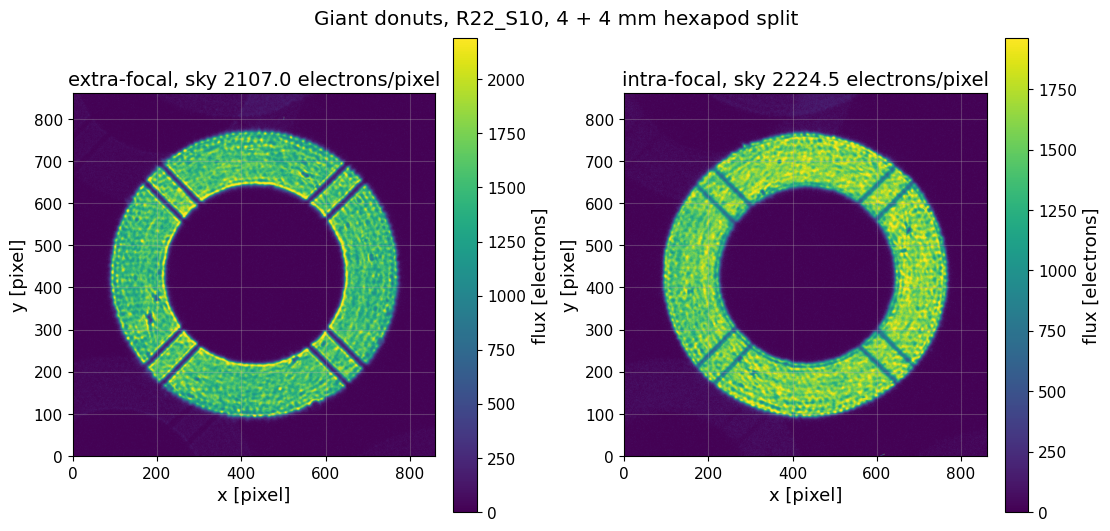

In [6]:
stamps = {}
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, (side, image) in zip(axes, images.items()):
    stamp, sky = di.cut_stamp(image, *positions[side], half=stamp_half_pix)
    stamps[side] = stamp
    if stamp is None:
        ax.set_title(f"{side}: stamp off detector")
        continue
    vmax = np.nanpercentile(stamp, 99.5)
    im = ax.imshow(stamp, origin="lower", vmin=0, vmax=vmax, cmap="viridis")
    ax.set_title(f"{side}-focal, sky {sky:.1f} electrons/pixel")
    ax.set_xlabel("x [pixel]")
    ax.set_ylabel("y [pixel]")
    fig.colorbar(im, ax=ax, label="flux [electrons]")
fig.suptitle(f"Giant donuts, {detector_name}, 4 + 4 mm hexapod split")


<a id='binning'></a>
## Binning

Both profiles are **resolution-limited, not noise-limited**: at one pixel per
radial bin the signal-to-noise per bin is already of order 1000, so shrinking
bins costs almost nothing in noise and the only question is whether a bin is
coarse enough to average a feature away.

The scans below choose the bin sizes by measuring where the features stop
changing. Two statistics:

- **amplitude** — the feature's measured size. Too-coarse bins average it down,
  so it rises as bins shrink, then plateaus. The plateau is the answer.
- **lag-1 autocorrelation** — whether neighbouring bins track the same feature.
  Negative means oversmoothed. Rising through 0.5–0.7 means resolved.
  Saturating toward 1.0 means the curve is already resolved and extra bins just
  subdivide it.

The radial scan is below. The azimuthal scan needs the fitted outer
edge, so it sits at the top of the Azimuthal profiles section.


In [7]:
for side, stamp in stamps.items():
    if stamp is None:
        continue
    print(f"--- {side}-focal, radial ---")
    print(f"{'bins':>6} {'pix/bin':>8} {'ring zone':>10} {'edge width':>11} "
          f"{'med err':>9}")
    for row in rp.bin_convergence(stamp, kind='radial'):
        print(f"{row['n_bins']:>6} {row['bin_size']:>8.2f} "
              f"{row['amplitude']:>10.4f} {row['edge_width']:>8.1f} pix "
              f"{row['median_err']:>9.5f}")

print(f"\nChosen: {rp.RADIAL_BIN_PIX} pixel per bin ({n_radial_bins} bins).")
print("Two things converge by this width and not before. The ring-zone mean "
      "settles\nnear 0.86 (intra) and 1.00 (extra); at 2.15 pixel per bin it "
      "reads about 12 per\ncent high, and at 3.6 pixel per bin it collapses "
      "and mislocates the peak to the\nouter edge. The outer-edge roll-off "
      "width also stops shrinking here.")
print("\nThe lag-1 autocorrelation is not shown for the radial profile: it "
      "exceeds 0.98\nat every bin width, because a smooth monotonic curve "
      "always correlates between\nneighbouring bins. It is diagnostic "
      "azimuthally, where the structure is not\nmonotonic.")


--- extra-focal, radial ---
  bins  pix/bin  ring zone  edge width   med err


    80     5.38     1.0161     15.9 pix   0.00233
   120     3.59     0.9561     14.2 pix   0.00285
   172     2.50     0.9778     12.4 pix   0.00337
   200     2.15     1.0163     12.8 pix   0.00366
   286     1.51     0.9959     13.4 pix   0.00436
   430     1.00     1.0030     12.9 pix   0.00542
   860     0.50     0.9952     12.9 pix   0.00751
--- intra-focal, radial ---
  bins  pix/bin  ring zone  edge width   med err


    80     5.38     0.8836     42.9 pix   0.00229
   120     3.59     0.9025     35.8 pix   0.00277
   172     2.50     0.8402     10.0 pix   0.00332
   200     2.15     0.8632     38.6 pix   0.00354
   286     1.51     0.8595     39.0 pix   0.00429
   430     1.00     0.8691      9.0 pix   0.00523
   860     0.50     0.8583      9.0 pix   0.00722

Chosen: 1.5 pixel per bin (287 bins).
Two things converge by this width and not before. The ring-zone mean settles
near 0.86 (intra) and 1.00 (extra); at 2.15 pixel per bin it reads about 12 per
cent high, and at 3.6 pixel per bin it collapses and mislocates the peak to the
outer edge. The outer-edge roll-off width also stops shrinking here.

The lag-1 autocorrelation is not shown for the radial profile: it exceeds 0.98
at every bin width, because a smooth monotonic curve always correlates between
neighbouring bins. It is diagnostic azimuthally, where the structure is not
monotonic.


<a id='analysis'></a>
## Analysis

Radial profiles, normalised so radius is 1.0 at the fitted outer edge and flux has
unit mean over the illuminated annulus. Both normalisations are needed before the
two sides can be compared: the intra and extra donuts differ in size and in total
flux for reasons that have nothing to do with the ring.

In [8]:
profiles = {}
for side, stamp in stamps.items():
    if stamp is None:
        continue
    r_pix, flux, flux_err, n_pix = rp.radial_profile(stamp, n_bins=n_radial_bins)
    r_norm, flux_norm, r_edge_pix = rp.normalise_profile(r_pix, flux)
    profiles[side] = dict(r_pix=r_pix, flux=flux, flux_err=flux_err,
                          r_norm=r_norm, flux_norm=flux_norm,
                          r_edge_pix=r_edge_pix)
    print(f"{side:>5}  fitted outer edge {r_edge_pix:.1f} pixel  "
          f"({r_edge_pix * 10e-3:.2f} mm at the 10 um pixel)")


extra  fitted outer edge 341.5 pixel  (3.42 mm at the 10 um pixel)


intra  fitted outer edge 335.7 pixel  (3.36 mm at the 10 um pixel)


In [9]:
# Ring excess at the inner edge, per side and per pupil model's inner radius.
# Referenced to a local baseline further out in the annulus, so it measures the
# ring rather than the step from the central hole.
print(f"{'side':>6}  {'model':>6}  {'edge_norm':>10}  {'ring_excess':>12}")
for side, prof in profiles.items():
    for model, edge_norm in rp.INNER_EDGE_NORM.items():
        excess = rp.ring_excess(prof["r_norm"], prof["flux_norm"], edge_norm)
        print(f"{side:>6}  {model:>6}  {edge_norm:>10.4f}  {excess:>+12.4f}")
print("\nring_excess is dimensionless: normalised flux in the band just outside "
      "the\ninner edge minus the local baseline further out in the annulus.")


  side   model   edge_norm   ring_excess
 extra   v3.14      0.6120       -0.0626
 extra   v1000      0.6204       +0.0132
 intra   v3.14      0.6120       -0.3120
 intra   v1000      0.6204       -0.2106

ring_excess is dimensionless: normalised flux in the band just outside the
inner edge minus the local baseline further out in the annulus.


In [10]:
# Zone statistics: the quantitative form of the diagnostic.
#
# The inner ring zone sits just outside the inner pupil edge, the outer zone just
# inside the rim. An OPD term moves flux between them in opposite directions on
# the two sides of focus; a mask boundary error would instead move an edge
# position the same way on both sides.
ZONES = {"inner ring": (0.62, 0.70), "outer": (0.94, 1.00)}

print(f"{'zone':<12} {'range':>12} {'extra':>9} {'intra':>9} {'extra-intra':>12}")
for name, (lo, hi) in ZONES.items():
    means = {}
    for side, prof in profiles.items():
        sel = (np.isfinite(prof["flux_norm"]) & (prof["r_norm"] >= lo)
               & (prof["r_norm"] < hi))
        means[side] = float(np.mean(prof["flux_norm"][sel])) if sel.any() else np.nan
    difference = means.get("extra", np.nan) - means.get("intra", np.nan)
    print(f"{name:<12} {f'{lo:.2f}-{hi:.2f}':>12} {means.get('extra', np.nan):>9.4f} "
          f"{means.get('intra', np.nan):>9.4f} {difference:>+12.4f}")
print("\nAll values are normalised flux, dimensionless, relative to the mean over "
      "the\nilluminated annulus.")


zone                range     extra     intra  extra-intra
inner ring      0.62-0.70    1.0073    0.8532      +0.1541
outer           0.94-1.00    0.8803    0.9760      -0.0957

All values are normalised flux, dimensionless, relative to the mean over the
illuminated annulus.


<a id='results'></a>
## Results & Plots

The top panel is the two normalised profiles. The bottom panel is the diagnostic:
intra minus extra. A **mask boundary** error gives a narrow feature at the edges
whose position shifts with the pupil model. An **OPD** error such as a turned-down
M1 inner edge gives a feature at the inner edge that **reverses sign** between the
two sides, with a compensating deficit beside it.

largest intra-minus-extra difference -0.3330 (dimensionless) at normalised radius 0.648


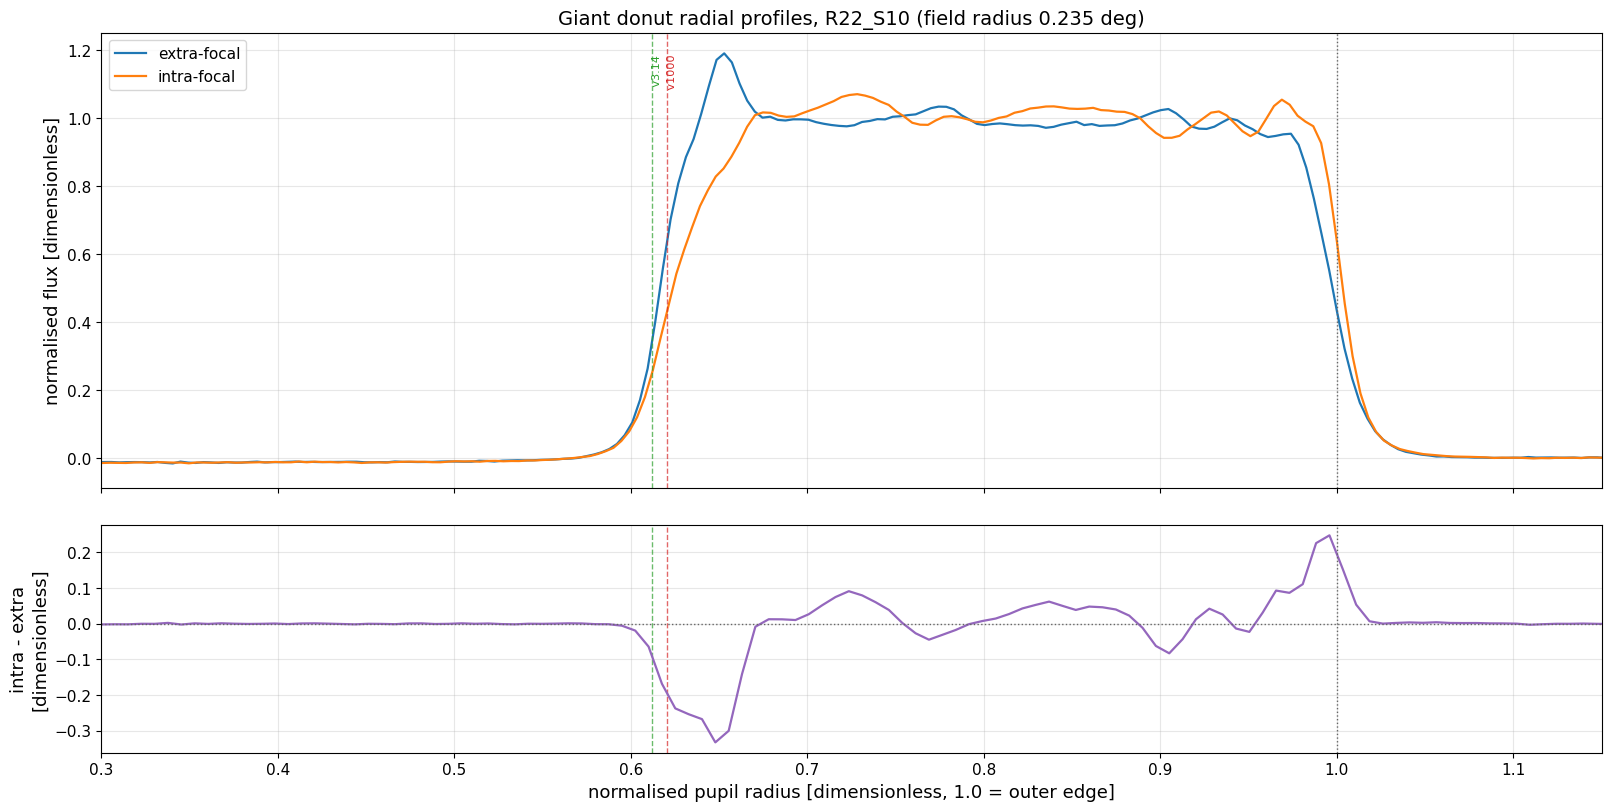

In [11]:
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(16, 8), sharex=True,
    gridspec_kw=dict(height_ratios=[2, 1], hspace=0.08))

for side, prof in profiles.items():
    ax_top.plot(prof["r_norm"], prof["flux_norm"], lw=1.6, label=f"{side}-focal")

for model, edge_norm in rp.INNER_EDGE_NORM.items():
    for ax in (ax_top, ax_bot):
        ax.axvline(edge_norm, ls="--", lw=1.0, alpha=0.7,
                   color="C2" if model == "v3.14" else "C3")
    ax_top.text(edge_norm, ax_top.get_ylim()[1] * 0.95, f" {model}",
                rotation=90, va="top", fontsize=8,
                color="C2" if model == "v3.14" else "C3")

ax_top.axvline(1.0, ls=":", lw=1.0, color="0.4")
ax_top.set_ylabel("normalised flux [dimensionless]")
ax_top.legend(loc="upper left")
ax_top.set_title(f"Giant donut radial profiles, {detector_name} "
                 f"(field radius 0.235 deg)")

if {"intra", "extra"} <= set(profiles):
    r_grid, difference = rp.profile_difference(
        profiles["intra"]["r_norm"], profiles["intra"]["flux_norm"],
        profiles["extra"]["r_norm"], profiles["extra"]["flux_norm"])
    ax_bot.plot(r_grid, difference, lw=1.6, color="C4")
    ax_bot.axhline(0.0, ls=":", lw=1.0, color="0.4")
    ax_bot.axvline(1.0, ls=":", lw=1.0, color="0.4")
    peak = int(np.nanargmax(np.abs(difference)))
    print(f"largest intra-minus-extra difference {difference[peak]:+.4f} "
          f"(dimensionless) at normalised radius {r_grid[peak]:.3f}")

ax_bot.set_xlabel("normalised pupil radius [dimensionless, 1.0 = outer edge]")
ax_bot.set_ylabel("intra - extra\n[dimensionless]")
ax_bot.set_xlim(0.3, 1.15)
fig.savefig(f"{output_dir}/radial_profiles_{detector_name}.pdf",
            bbox_inches="tight")


<a id='azimuthal'></a>
## Azimuthal profiles

The radial profile averages over azimuth, so it dilutes anything localised. This
is the complementary cut: average over radius within an annulus that excludes
both edges, and look at the variation with angle.

Two features are expected and should be told apart. The **spiders** give narrow,
regularly spaced dips at the same azimuth on both sides of focus. A **localised
figure error** gives a broader modulation at one azimuth and, being an OPD term,
should reverse sign between intra and extra.

In [12]:
for side, stamp in stamps.items():
    if stamp is None:
        continue
    print(f"--- {side}-focal, azimuthal ---")
    print(f"{'bins':>6} {'deg/bin':>8} {'peak-to-peak':>13} {'med err':>9} "
          f"{'p2p/err':>8} {'autocorr':>9}")
    for row in rp.bin_convergence(stamp, kind='azimuthal',
                                  r_edge_pix=profiles[side]['r_edge_pix'],
                                  r_range_norm=azimuthal_annulus):
        ratio = row['amplitude'] / row['median_err'] if row['median_err'] else np.nan
        print(f"{row['n_bins']:>6} {row['bin_size']:>8.2f} "
              f"{row['amplitude']:>13.4f} {row['median_err']:>9.5f} "
              f"{ratio:>8.0f} {row['autocorr']:>9.3f}")

vane_deg = np.degrees(2 * np.arcsin(rp.SPIDER_WIDTH_M / 2
                                    / (0.8 * instrument_radius_m)))
print(f"\nA {rp.SPIDER_WIDTH_M} m spider vane at 0.8 of the pupil radius subtends "
      f"{vane_deg:.2f} deg, so\nthe 5 deg bins this study started with washed the "
      f"vanes out entirely, and 1.0 deg\nresolves a vane with a single bin.")
print(f"Chosen: {rp.AZIMUTHAL_BIN_DEG} deg per bin ({n_azimuthal_bins} bins), about "
      f"{vane_deg / rp.AZIMUTHAL_BIN_DEG:.1f} bins across\na vane, which resolves "
      f"its profile rather than just its presence. Peak-to-peak has\nconverged by "
      f"this width, and p2p/err stays well above 10, so the vanes are far\nabove "
      f"the noise even at {int(round(489 * rp.AZIMUTHAL_BIN_DEG))} or so pixels "
      f"per bin.")

--- extra-focal, azimuthal ---
  bins  deg/bin  peak-to-peak   med err  p2p/err  autocorr


    72     5.00        0.4392   0.00290      151    -0.213
   180     2.00        0.7600   0.00450      169     0.225
   360     1.00        0.9177   0.00623      147     0.671
   720     0.50        0.9889   0.00873      113     0.899
  1440     0.25        1.0150   0.01233       82     0.972
  1800     0.20        1.0182   0.01376       74     0.981
  2880     0.12        1.0364   0.01737       60     0.985
--- intra-focal, azimuthal ---
  bins  deg/bin  peak-to-peak   med err  p2p/err  autocorr


    72     5.00        0.2632   0.00256      103     0.076
   180     2.00        0.4528   0.00388      117     0.475
   360     1.00        0.5229   0.00536       98     0.787
   720     0.50        0.5593   0.00760       74     0.933
  1440     0.25        0.5711   0.01073       53     0.979
  1800     0.20        0.5682   0.01199       47     0.984
  2880     0.12        0.6143   0.01520       40     0.977

A 0.05 m spider vane at 0.8 of the pupil radius subtends 0.86 deg, so
the 5 deg bins this study started with washed the vanes out entirely, and 1.0 deg
resolves a vane with a single bin.
Chosen: 0.25 deg per bin (1440 bins), about 3.4 bins across
a vane, which resolves its profile rather than just its presence. Peak-to-peak has
converged by this width, and p2p/err stays well above 10, so the vanes are far
above the noise even at 122 or so pixels per bin.


In [13]:
azimuthal = {}
for side, stamp in stamps.items():
    if stamp is None:
        continue
    angle_deg, flux, flux_err, n_pix = rp.azimuthal_profile(
        stamp, n_bins=n_azimuthal_bins, r_range_norm=azimuthal_annulus,
        r_edge_pix=profiles[side]["r_edge_pix"])
    # Normalise to unit mean so the two sides are comparable in shape.
    scale = np.nanmean(flux)
    azimuthal[side] = dict(angle_deg=angle_deg, flux_norm=flux / scale,
                           flux_err_norm=flux_err / scale, n_pix=n_pix)
    finite = np.isfinite(flux)
    print(f"{side:>5}  {int(finite.sum())} of {n_azimuthal_bins} bins populated, "
          f"median {int(np.median(n_pix))} pixel per bin, "
          f"peak-to-peak {np.nanmax(flux / scale) - np.nanmin(flux / scale):.4f} "
          f"(dimensionless)")

extra  1440 of 1440 bins populated, median 122 pixel per bin, peak-to-peak 1.0150 (dimensionless)


intra  1440 of 1440 bins populated, median 118 pixel per bin, peak-to-peak 0.5711 (dimensionless)


largest intra-minus-extra azimuthal difference +0.5920 (dimensionless) at 140.4 deg


robust scatter of the difference 0.0543 (dimensionless)


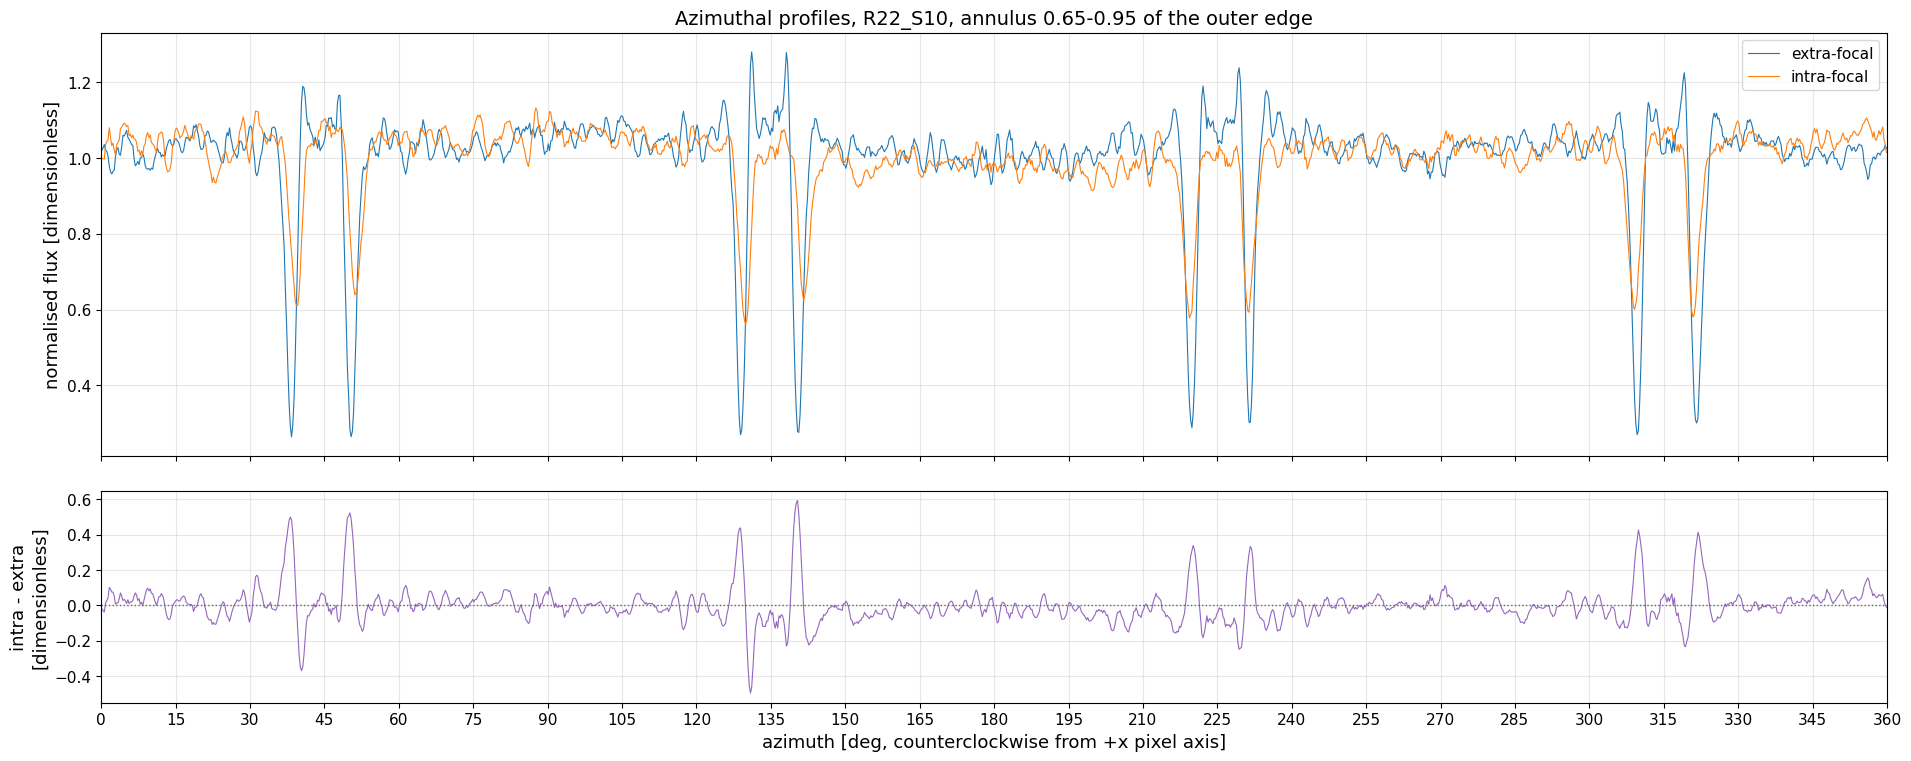

In [14]:
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(19, 7.5), sharex=True,
    gridspec_kw=dict(height_ratios=[2, 1], hspace=0.08))

for side, prof in azimuthal.items():
    ax_top.plot(prof["angle_deg"], prof["flux_norm"], lw=0.8, label=f"{side}-focal")

ax_top.set_ylabel("normalised flux [dimensionless]")
ax_top.legend(loc="upper right")
ax_top.set_title(f"Azimuthal profiles, {detector_name}, annulus "
                 f"{azimuthal_annulus[0]:.2f}-{azimuthal_annulus[1]:.2f} "
                 f"of the outer edge")

if {"intra", "extra"} <= set(azimuthal):
    difference = azimuthal["intra"]["flux_norm"] - azimuthal["extra"]["flux_norm"]
    ax_bot.plot(azimuthal["intra"]["angle_deg"], difference, lw=0.8, color="C4")
    ax_bot.axhline(0.0, ls=":", lw=1.0, color="0.4")
    peak = int(np.nanargmax(np.abs(difference)))
    print(f"largest intra-minus-extra azimuthal difference "
          f"{difference[peak]:+.4f} (dimensionless) at "
          f"{azimuthal['intra']['angle_deg'][peak]:.1f} deg")
    print(f"robust scatter of the difference "
          f"{1.48 * np.nanmedian(np.abs(difference - np.nanmedian(difference))):.4f} "
          f"(dimensionless)")

ax_bot.set_xlabel("azimuth [deg, counterclockwise from +x pixel axis]")
ax_bot.set_ylabel("intra - extra\n[dimensionless]")
ax_bot.set_xlim(0, 360)
ax_bot.set_xticks(np.arange(0, 361, 15))
fig.savefig(f"{output_dir}/azimuthal_profiles_{detector_name}.pdf",
            bbox_inches="tight")

<a id='fits'></a>
## Wavefront fits: two pupil models, spiders off and on

Fits use blitz's own danish factory and forward model, driven directly rather
than through the butler pipeline — this engineering night has no reference
catalog or matched calibrations, and the question is about the forward model.

The defocus is the measured 4 + 4 mm split: 4.0 mm on the camera hexapod and
4.0 mm on M2, signed positive extra-focal.

`maskParams` alone does not change the pupil model. blitz carries the pupil
twice — the analytic mask danish uses *and* a batoid telescope supplying the
reference wavefront — so `fg.pupil_override` swaps both together.

In [15]:
# _import_blitz repairs the frozen lsst.ts namespace path, so this works
# even though lsst.daf.butler was imported above. It verifies that blitz
# AND its ts_wep siblings all come from this checkout.
blitz_utils, wf_task = fg._import_blitz(fit_blitz_python)
print("blitz from", blitz_utils.__file__)

fits = {}
for model_name, spiders in FIT_CONFIGS:
    fg.pupil_override(
        blitz_utils, model_name,
        mask_params_file=(mask_params_v1000 if model_name == "v1000" else None))

    for blur in BLUR_MODES:
        for side, stamp in stamps.items():
            if stamp is None:
                continue
            sign = +1.0 if side == "extra" else -1.0
            offsets = tuple(sign * o for o in fg.EXTRA_OFFSETS_M)
            x_pix, y_pix = positions[side]
            ax_deg, ay_deg = di.field_angle_deg(detector_name, x_pix, y_pix,
                                                camera)

            fits[(model_name, spiders, blur, side)] = fg.fit_stamp(
                stamp, np.deg2rad(ax_deg), np.deg2rad(ay_deg), offsets,
                blitz_utils, wf_task, fwhm_max=fwhm_max_arcsec,
                fwhm_fixed=(fwhm_fixed_arcsec if blur == "fixed" else None),
                spiders=spiders, tol=fit_tol, max_nfev=300)

print(f"{len(fits)} fits done: {len(FIT_CONFIGS)} configurations "
      f"x {len(BLUR_MODES)} blur modes x {len(stamps)} sides")

blitz from /sdf/home/r/roodman/u/LSST/packages/ts_wep_blitz/python/lsst/ts/wep/blitz/utils.py


16 fits done: 4 configurations x 2 blur modes x 2 sides


In [16]:
# The 2x2 of pupil model against spiders, for each blur treatment, and the Z11
# split that item 7 is about.
dof = fits[(FIT_CONFIGS[0][0], FIT_CONFIGS[0][1], "free", "extra")]["dof"]
for blur in BLUR_MODES:
    tag = (f"blur free, 0.1 to {fwhm_max_arcsec} arcsec" if blur == "free"
           else f"blur fixed at {fwhm_fixed_arcsec} arcsec")
    print(f"=== {tag} ===")
    print(f"{'model':7s} {'spiders':8s} {'chi2/dof extra':>15s} "
          f"{'chi2/dof intra':>15s} {'Z11 split':>11s}")
    print(f"{'':16s}{'[dof ' + str(dof) + ']':>15s}{'':15s}{'[um wf]':>12s}")
    for model_name, spiders in FIT_CONFIGS:
        e = fits[(model_name, spiders, blur, "extra")]
        i = fits[(model_name, spiders, blur, "intra")]
        split = i["zk_dev_um"][fg.NOLL_Z11] - e["zk_dev_um"][fg.NOLL_Z11]
        print(f"{model_name:7s} {'on' if spiders else 'off':8s} "
              f"{e['chi2_per_dof']:>15.3f} {i['chi2_per_dof']:>15.3f} "
              f"{split:>+11.4f}")
    print()

print("Z11 split is intra minus extra, in um of wavefront. The data show about "
      "0.30 um,\nof which diffraction accounts for about 0.10 um.")

print(f"\n{'model':7s} {'spiders':8s} {'blur':>6s} {'side':>6s} "
      f"{'blur FWHM':>11s} {'at bound':>9s}")
for model_name, spiders in FIT_CONFIGS:
    for blur in BLUR_MODES:
        for side in ("extra", "intra"):
            f = fits[(model_name, spiders, blur, side)]
            print(f"{model_name:7s} {'on' if spiders else 'off':8s} "
                  f"{blur:>6s} {side:>6s} {f['fwhm_arcsec']:>8.3f} as "
                  f"{'yes' if f['fwhm_at_bound'] else 'no':>9s}")
print(f"\nFree-blur bound is 0.1 to {fwhm_max_arcsec} arcsec; a fit on the bound "
      f"has not measured\nthe blur. Fixed-blur fits are held at "
      f"{fwhm_fixed_arcsec} arcsec by construction, so 'at bound'\nis not "
      f"meaningful for them.")


=== blur free, 0.1 to 3.0 arcsec ===
model   spiders   chi2/dof extra  chi2/dof intra   Z11 split
                   [dof 184015]                    [um wf]
v3.14   off               14.994           7.132     +0.8043
v3.14   on                12.004           6.005     +0.7914
v1000   off               14.895           7.141     +0.3618
v1000   on                11.822           5.984     +0.3515

=== blur fixed at 0.7 arcsec ===
model   spiders   chi2/dof extra  chi2/dof intra   Z11 split
                   [dof 184015]                    [um wf]
v3.14   off               15.184           7.954     +0.7782
v3.14   on                12.259           7.745     +0.7556
v1000   off               15.098           8.022     +0.3323
v1000   on                12.077           7.764     +0.3119

Z11 split is intra minus extra, in um of wavefront. The data show about 0.30 um,
of which diffraction accounts for about 0.10 um.

model   spiders    blur   side   blur FWHM  at bound
v3.14   off     

<a id='zktable'></a>
## Fitted Zernikes and blur

Noll Z4 (defocus), Z11 (primary spherical) and Z22 (secondary spherical) from
each of the eight fits, with the fitted blur, and the intra-minus-extra split of
each coefficient. Z4 is reported for completeness only: injecting the v1000 mask
while the danish pupil radii come from the same model makes Z4 absorb the
pupil-scale/defocus degeneracy, so its value is not a measurement of the
telescope's defocus.

In [17]:
ZK_REPORT = {4: "Z4 (defocus)", 11: "Z11 (spherical)", 22: "Z22 (2nd spher.)"}

for blur in BLUR_MODES:
    tag = (f"blur free, 0.1 to {fwhm_max_arcsec} arcsec" if blur == "free"
           else f"blur fixed at {fwhm_fixed_arcsec} arcsec")
    header = (f"{'model':7s} {'spiders':8s} {'side':>6s}"
              + "".join(f"{f'Z{j}':>10s}" for j in ZK_REPORT)
              + f"{'blur':>9s} {'at bound':>9s}")
    print(f"=== {tag} ===")
    print(header)
    print(f"{'':22s}" + "".join(f"{'[um wf]':>10s}" for j in ZK_REPORT)
          + f"{'[arcsec]':>9s}")
    print("-" * len(header))
    for model_name, spiders in FIT_CONFIGS:
        for side in ("extra", "intra"):
            f = fits[(model_name, spiders, blur, side)]
            print(f"{model_name:7s} {'on' if spiders else 'off':8s} {side:>6s}"
                  + "".join(f"{f['zk_dev_um'][j]:>+10.4f}" for j in ZK_REPORT)
                  + f"{f['fwhm_arcsec']:>9.3f} "
                  + f"{'yes' if f['fwhm_at_bound'] else 'no':>8s}")
    print()

split_header = (f"{'model':7s} {'spiders':8s} {'blur':>6s}"
                + "".join(f"{f'dZ{j}':>10s}" for j in ZK_REPORT)
                + f"{'d blur':>9s}")
print(split_header)
print(f"{'':22s}" + "".join(f"{'[um wf]':>10s}" for j in ZK_REPORT)
      + f"{'[arcsec]':>9s}")
print("-" * len(split_header))
for blur in BLUR_MODES:
    for model_name, spiders in FIT_CONFIGS:
        e = fits[(model_name, spiders, blur, "extra")]
        i = fits[(model_name, spiders, blur, "intra")]
        print(f"{model_name:7s} {'on' if spiders else 'off':8s} {blur:>6s}"
              + "".join(f"{i['zk_dev_um'][j] - e['zk_dev_um'][j]:>+10.4f}"
                        for j in ZK_REPORT)
              + f"{i['fwhm_arcsec'] - e['fwhm_arcsec']:>+9.3f}")

print("\nSplit is intra minus extra. Z4, Z11 and Z22 are Noll coefficients of "
      "the\nwavefront deviation from the design, in um of wavefront; blur is the "
      "fitted\nGaussian FWHM in arcsec. A free-blur fit on the bound has not "
      "measured the blur,\nso the blur split it implies is a lower limit.")
print("\nZ4 is a diagnostic of the pupil-scale/defocus degeneracy, not a "
      "measurement of\nthe telescope's defocus -- see the Interpretation "
      "section.")


=== blur free, 0.1 to 3.0 arcsec ===
model   spiders    side        Z4       Z11       Z22     blur  at bound
                         [um wf]   [um wf]   [um wf] [arcsec]
------------------------------------------------------------------------
v3.14   off       extra   +0.6443   -0.4298   +0.0876    1.009       no
v3.14   off       intra   +0.4267   +0.3745   +0.0139    1.509       no
v3.14   on        extra   +0.4600   -0.4146   +0.1017    0.985       no
v3.14   on        intra   +0.4989   +0.3769   +0.0058    1.645       no
v1000   off       extra   +0.5023   -0.2040   +0.0564    1.018       no
v1000   off       intra   +0.5228   +0.1578   +0.0427    1.541       no
v1000   on        extra   +0.3219   -0.1916   +0.0711    0.984       no
v1000   on        intra   +0.5958   +0.1600   +0.0345    1.662       no

=== blur fixed at 0.7 arcsec ===
model   spiders    side        Z4       Z11       Z22     blur  at bound
                         [um wf]   [um wf]   [um wf] [arcsec]
----------

### Fit overlays on the radial profiles

Each fit's model image is profiled exactly as the data was, then overlaid.
Separate panels per side of focus, because the two sides are different
measurements and overplotting them hides which model fails where.

The model images are on the binned grid, so they are compared in normalised
radius rather than pixels.

model   spiders    blur   side   nMAD resid
v3.14   off        free  extra       0.0243
v3.14   off        free  intra       0.0268
v3.14   on         free  extra       0.0256
v3.14   on         free  intra       0.0282
v1000   off        free  extra       0.0216
v1000   off        free  intra       0.0273
v1000   on         free  extra       0.0268
v1000   on         free  intra       0.0278
v3.14   off       fixed  extra       0.0257
v3.14   off       fixed  intra       0.0238
v3.14   on        fixed  extra       0.0288
v3.14   on        fixed  intra       0.0245
v1000   off       fixed  extra       0.0270
v1000   off       fixed  intra       0.0267
v1000   on        fixed  extra       0.0312
v1000   on        fixed  intra       0.0267

nMAD of the data-minus-model normalised flux over the flat annulus 0.65-0.95,
dimensionless. Lower is a better radial match.


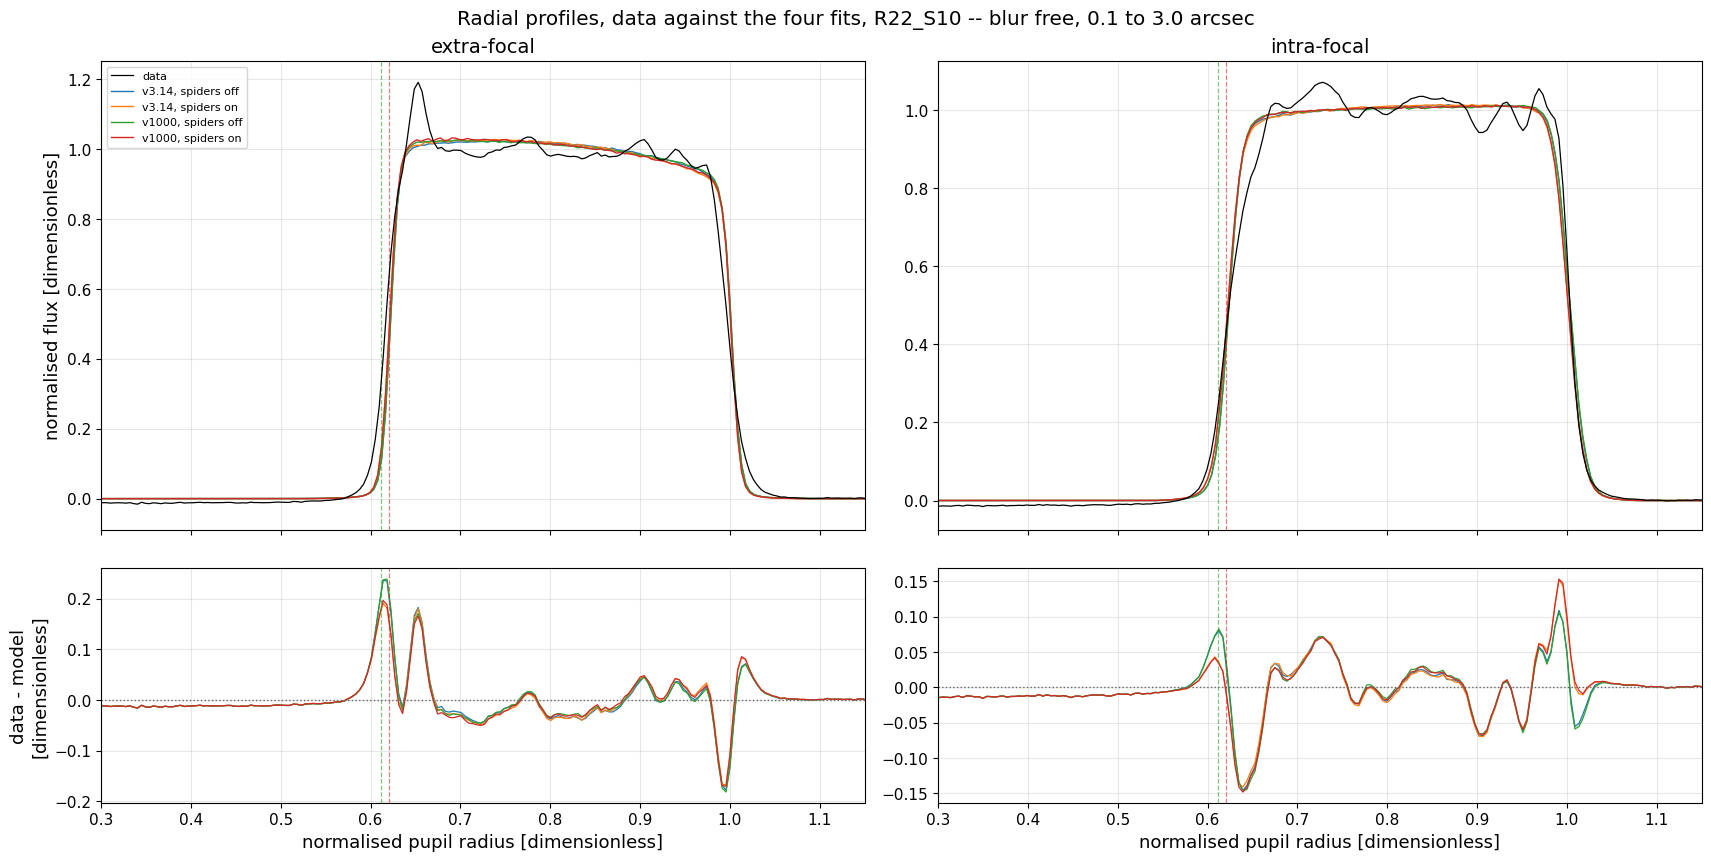

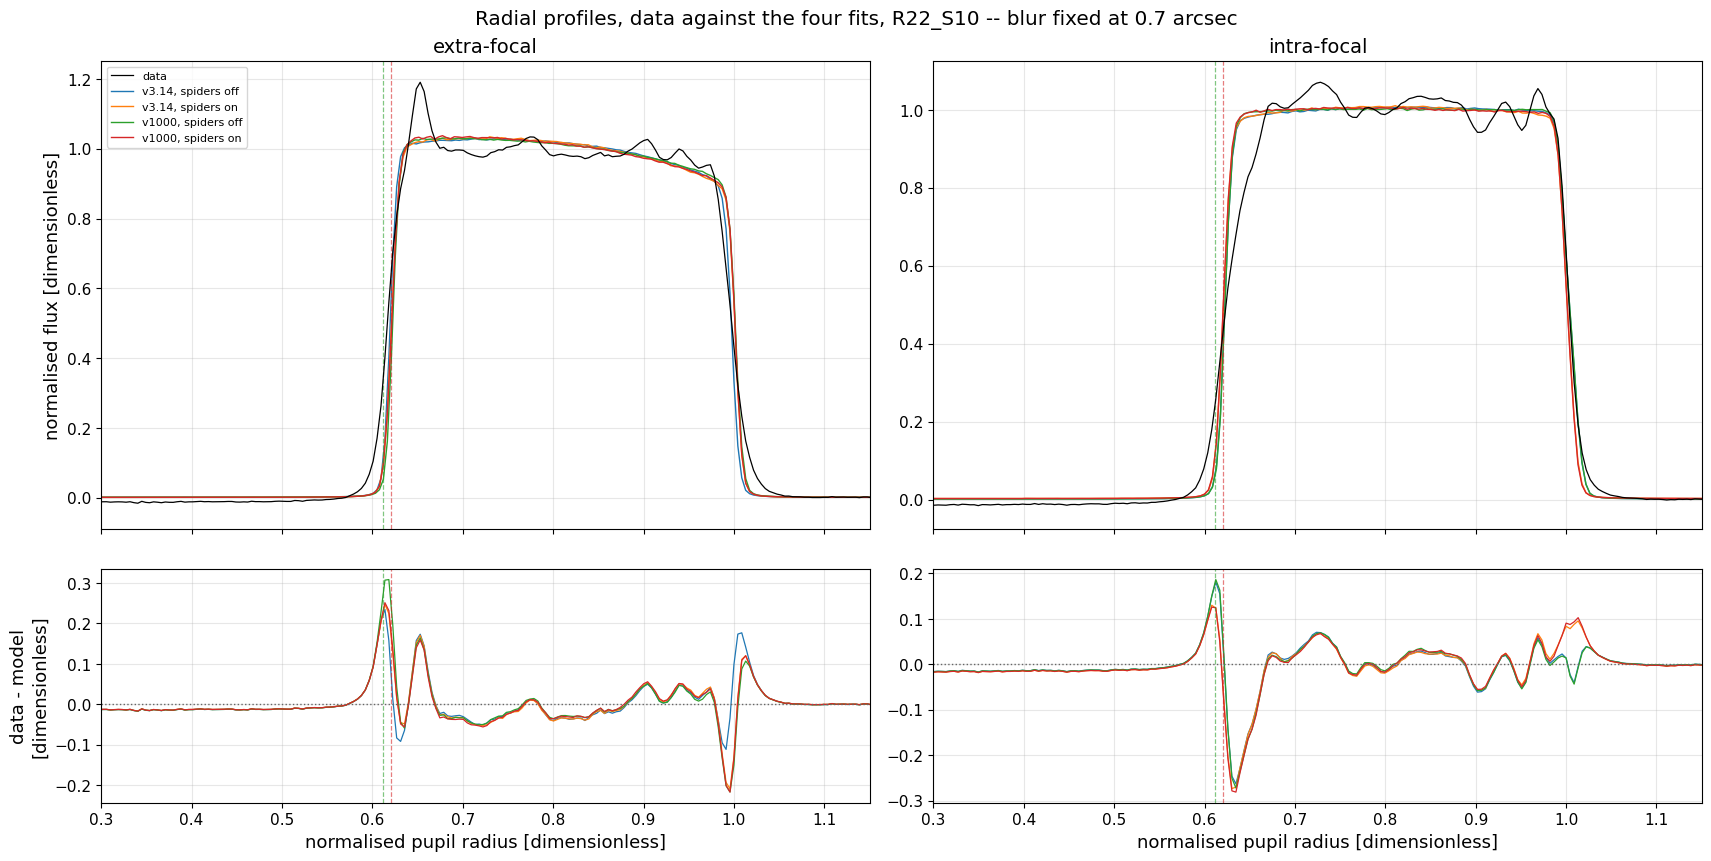

In [18]:
fit_radial = {}
for key, f in fits.items():
    r_pix, flux, flux_err, n_pix = rp.radial_profile(
        f["model_img"], n_bins=n_radial_bins)
    r_norm, flux_norm, r_edge_pix = rp.normalise_profile(r_pix, flux)
    fit_radial[key] = dict(r_norm=r_norm, flux_norm=flux_norm,
                           r_edge_pix=r_edge_pix)

for blur in BLUR_MODES:
    tag = (f"blur free, 0.1 to {fwhm_max_arcsec} arcsec" if blur == "free"
           else f"blur fixed at {fwhm_fixed_arcsec} arcsec")
    fig, axes = plt.subplots(2, 2, figsize=(17, 8.5), sharex=True,
                             gridspec_kw=dict(height_ratios=[2, 1], hspace=0.08))

    for col, side in enumerate(("extra", "intra")):
        ax_top, ax_bot = axes[0, col], axes[1, col]
        data = profiles[side]
        ax_top.plot(data["r_norm"], data["flux_norm"], lw=0.9, color="k",
                    label="data", zorder=5)

        for n, (model_name, spiders) in enumerate(FIT_CONFIGS):
            prof = fit_radial[(model_name, spiders, blur, side)]
            label = f"{model_name}, spiders {'on' if spiders else 'off'}"
            ax_top.plot(prof["r_norm"], prof["flux_norm"], lw=1.0,
                        color=f"C{n}", label=label)
            model_on_data = np.interp(data["r_norm"], prof["r_norm"],
                                      prof["flux_norm"], left=np.nan,
                                      right=np.nan)
            ax_bot.plot(data["r_norm"], data["flux_norm"] - model_on_data,
                        lw=0.9, color=f"C{n}")

        for model_name, edge_norm in rp.INNER_EDGE_NORM.items():
            for ax in (ax_top, ax_bot):
                ax.axvline(edge_norm, ls="--", lw=0.9, alpha=0.6,
                           color="C2" if model_name == "v3.14" else "C3")
        ax_bot.axhline(0.0, ls=":", lw=1.0, color="0.4")
        ax_top.set_title(f"{side}-focal")
        ax_bot.set_xlabel("normalised pupil radius [dimensionless]")
        ax_bot.set_xlim(0.3, 1.15)
        if col == 0:
            ax_top.set_ylabel("normalised flux [dimensionless]")
            ax_bot.set_ylabel("data - model\n[dimensionless]")
            ax_top.legend(loc="upper left", fontsize=8)

    fig.suptitle(f"Radial profiles, data against the four fits, "
                 f"{detector_name} -- {tag}")
    fig.savefig(f"{output_dir}/radial_fits_{blur}blur_{detector_name}.pdf",
                bbox_inches="tight")

print(f"{'model':7s} {'spiders':8s} {'blur':>6s} {'side':>6s} {'nMAD resid':>12s}")
for blur in BLUR_MODES:
    for model_name, spiders in FIT_CONFIGS:
        for side in ("extra", "intra"):
            data = profiles[side]
            prof = fit_radial[(model_name, spiders, blur, side)]
            model_on_data = np.interp(data["r_norm"], prof["r_norm"],
                                      prof["flux_norm"], left=np.nan,
                                      right=np.nan)
            resid = data["flux_norm"] - model_on_data
            inside = (np.isfinite(resid) & (data["r_norm"] > 0.65)
                      & (data["r_norm"] < 0.95))
            nmad = 1.48 * np.nanmedian(
                np.abs(resid[inside] - np.nanmedian(resid[inside])))
            print(f"{model_name:7s} {'on' if spiders else 'off':8s} "
                  f"{blur:>6s} {side:>6s} {nmad:>12.4f}")
print("\nnMAD of the data-minus-model normalised flux over the flat annulus "
      "0.65-0.95,\ndimensionless. Lower is a better radial match.")


### Fit overlays on the azimuthal profiles

Same comparison, azimuthally. This is where the spider models should show
up: with `modelSpiderShadows` off, the model has no vanes and cannot
reproduce the dips.

model   spiders    blur   side   nMAD resid  vane depth
v3.14   off        free  extra       0.0451      0.0447
v3.14   off        free  intra       0.0380      0.0690
v3.14   on         free  extra       0.0435      0.3439
v3.14   on         free  intra       0.0382      0.3051
v1000   off        free  extra       0.0451      0.0433
v1000   off        free  intra       0.0390      0.0743
v1000   on         free  extra       0.0435      0.3545
v1000   on         free  intra       0.0378      0.3107
v3.14   off       fixed  extra       0.0458      0.0535
v3.14   off       fixed  intra       0.0387      0.0740
v3.14   on        fixed  extra       0.0443      0.3609
v3.14   on        fixed  intra       0.0422      0.3872
v1000   off       fixed  extra       0.0458      0.0883
v1000   off       fixed  intra       0.0386      0.0740
v1000   on        fixed  extra       0.0432      0.3710
v1000   on        fixed  intra       0.0418      0.4055
data  extra vane depth 0.7648 (dimensionless)
da

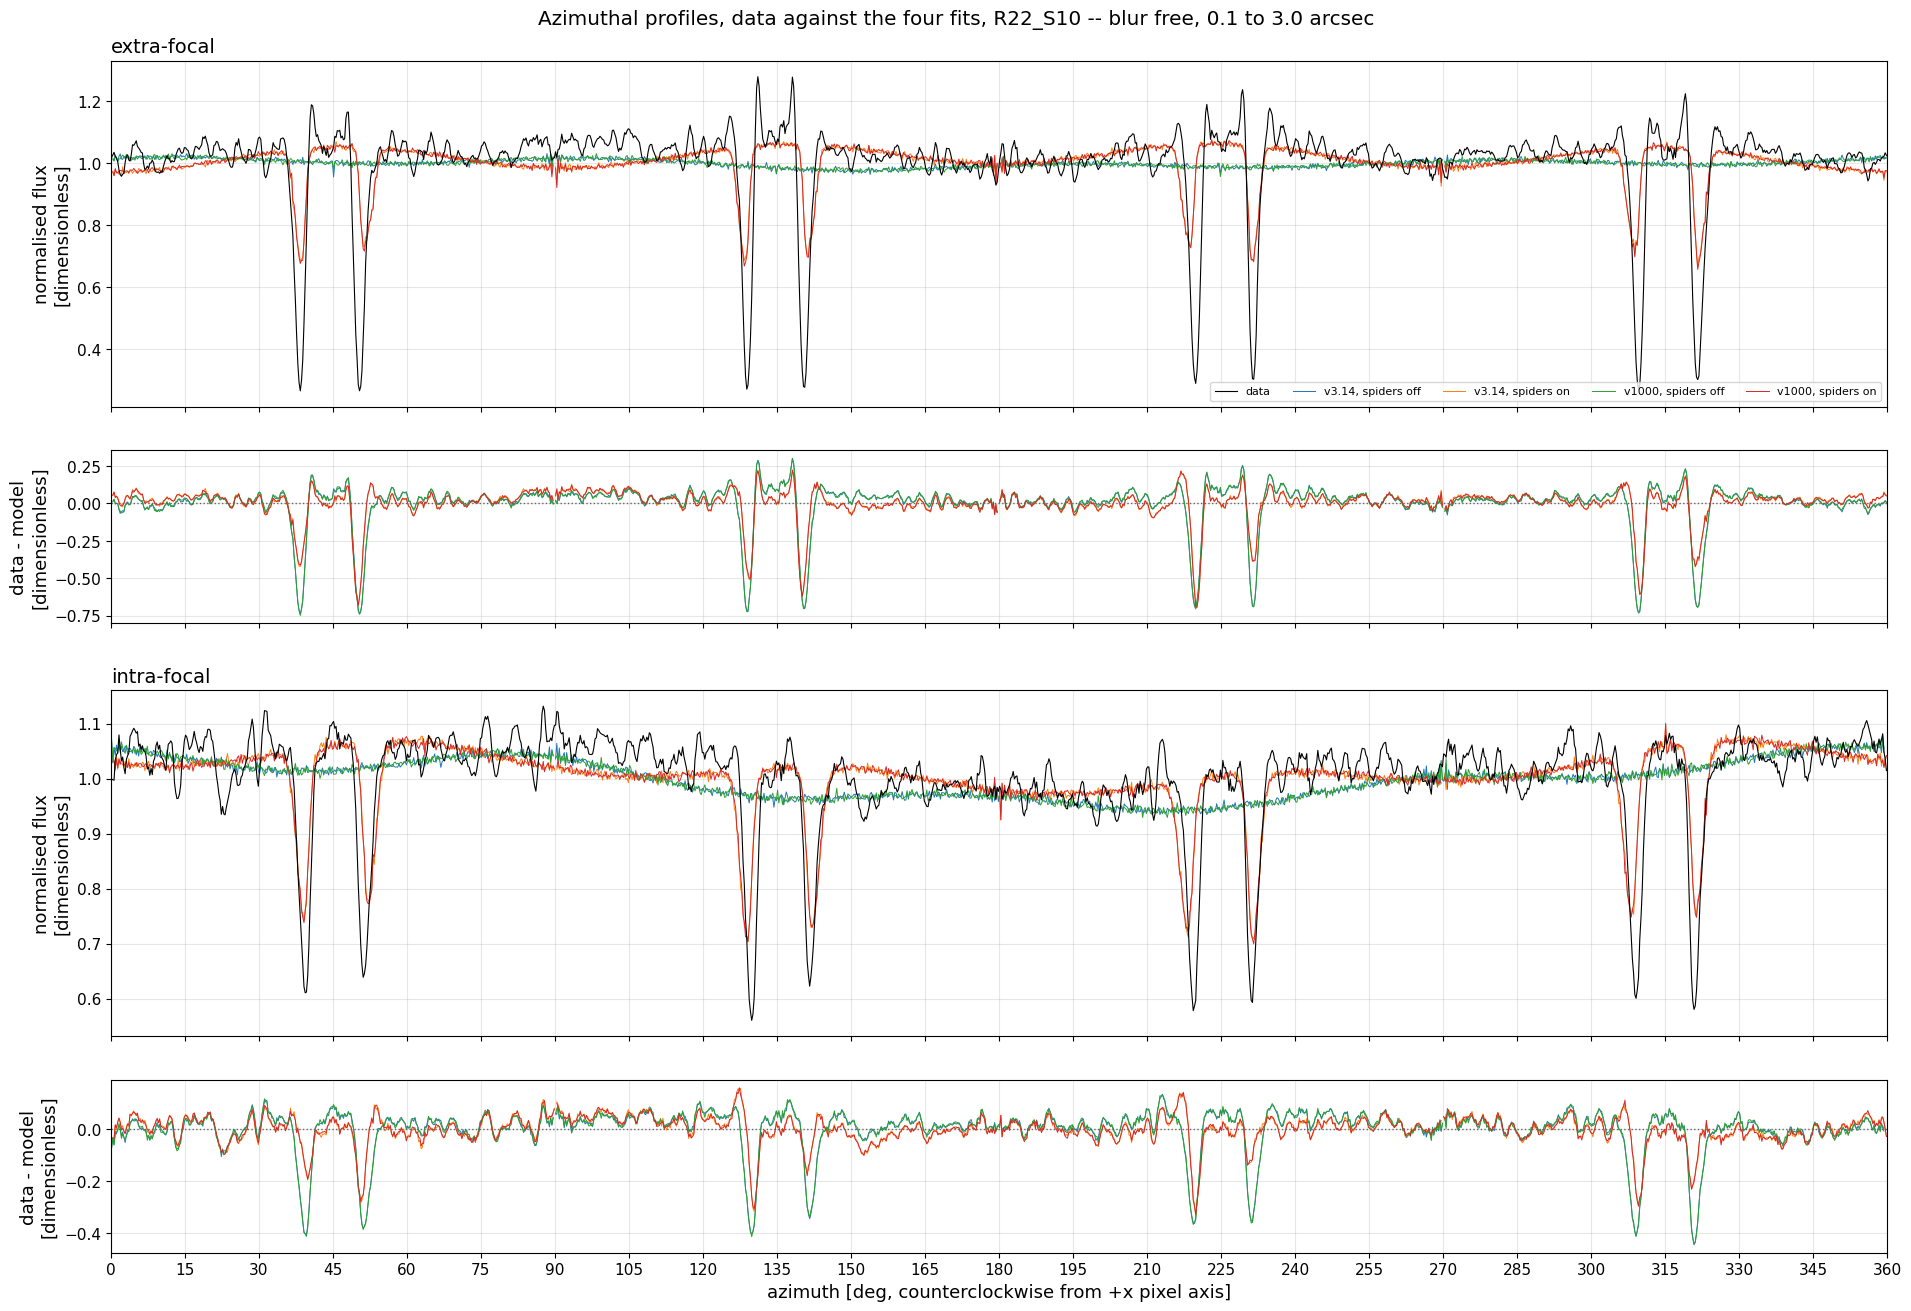

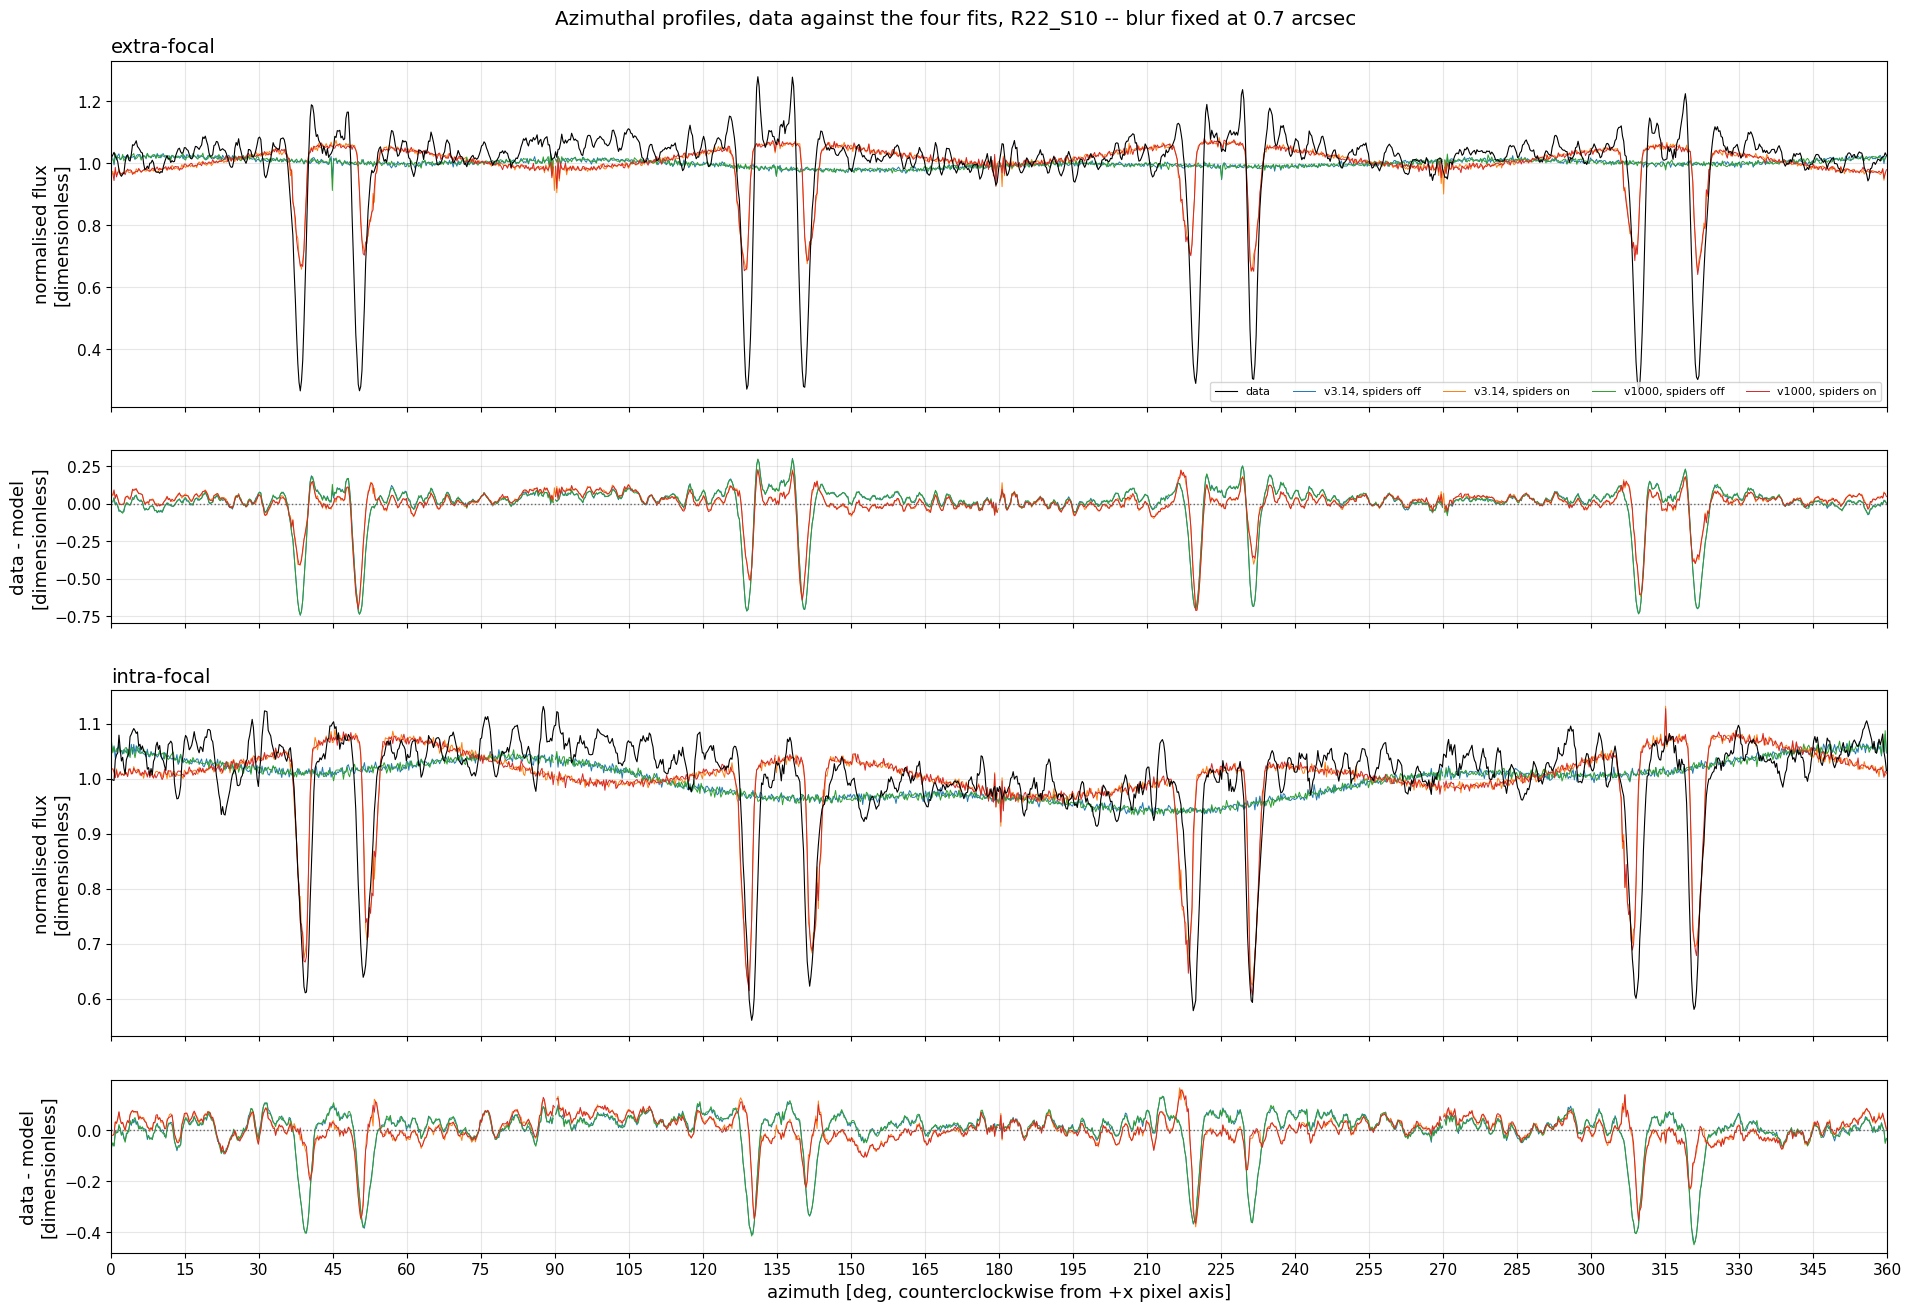

In [19]:
fit_azimuthal = {}
for key, f in fits.items():
    angle_deg, flux, flux_err, n_pix = rp.azimuthal_profile(
        f["model_img"], n_bins=n_azimuthal_bins, r_range_norm=azimuthal_annulus,
        r_edge_pix=fit_radial[key]["r_edge_pix"])
    fit_azimuthal[key] = dict(angle_deg=angle_deg,
                              flux_norm=flux / np.nanmean(flux))

# One full-width row per side, rather than two side-by-side columns: at
# 0.25 deg per bin the vane dips are only a few bins across, and splitting the
# page in half compresses 360 deg into an unreadable width.
for blur in BLUR_MODES:
    tag = (f"blur free, 0.1 to {fwhm_max_arcsec} arcsec" if blur == "free"
           else f"blur fixed at {fwhm_fixed_arcsec} arcsec")
    fig, axes = plt.subplots(4, 1, figsize=(19, 13), sharex=True,
                             gridspec_kw=dict(height_ratios=[2, 1, 2, 1],
                                              hspace=0.12))

    for row, side in enumerate(("extra", "intra")):
        ax_top, ax_bot = axes[2 * row], axes[2 * row + 1]
        data = azimuthal[side]
        ax_top.plot(data["angle_deg"], data["flux_norm"], lw=0.8, color="k",
                    label="data", zorder=5)

        for n, (model_name, spiders) in enumerate(FIT_CONFIGS):
            prof = fit_azimuthal[(model_name, spiders, blur, side)]
            label = f"{model_name}, spiders {'on' if spiders else 'off'}"
            ax_top.plot(prof["angle_deg"], prof["flux_norm"], lw=0.7,
                        color=f"C{n}", label=label)
            ax_bot.plot(data["angle_deg"],
                        data["flux_norm"] - prof["flux_norm"], lw=0.7,
                        color=f"C{n}")

        ax_bot.axhline(0.0, ls=":", lw=1.0, color="0.4")
        ax_top.set_title(f"{side}-focal", loc="left")
        ax_top.set_ylabel("normalised flux\n[dimensionless]")
        ax_bot.set_ylabel("data - model\n[dimensionless]")
        if row == 0:
            ax_top.legend(loc="lower right", fontsize=8, ncol=5)

    axes[-1].set_xlabel("azimuth [deg, counterclockwise from +x pixel axis]")
    axes[-1].set_xlim(0, 360)
    axes[-1].set_xticks(np.arange(0, 361, 15))
    fig.suptitle(f"Azimuthal profiles, data against the four fits, "
                 f"{detector_name} -- {tag}")
    fig.savefig(f"{output_dir}/azimuthal_fits_{blur}blur_{detector_name}.pdf",
                bbox_inches="tight")

print(f"{'model':7s} {'spiders':8s} {'blur':>6s} {'side':>6s} "
      f"{'nMAD resid':>12s} {'vane depth':>11s}")
for blur in BLUR_MODES:
    for model_name, spiders in FIT_CONFIGS:
        for side in ("extra", "intra"):
            key = (model_name, spiders, blur, side)
            resid = (azimuthal[side]["flux_norm"]
                     - fit_azimuthal[key]["flux_norm"])
            nmad = 1.48 * np.nanmedian(np.abs(resid - np.nanmedian(resid)))
            # Vane depth: how far below its own median the model's deepest
            # azimuthal dip goes, the quantity the spider shadow controls.
            v = fit_azimuthal[key]["flux_norm"]
            depth = float(np.nanmedian(v) - np.nanmin(v))
            print(f"{model_name:7s} {'on' if spiders else 'off':8s} "
                  f"{blur:>6s} {side:>6s} {nmad:>12.4f} {depth:>11.4f}")

for side in ("extra", "intra"):
    v = azimuthal[side]["flux_norm"]
    print(f"data {side:>6s} vane depth "
          f"{float(np.nanmedian(v) - np.nanmin(v)):.4f} (dimensionless)")
print("\nnMAD of the data-minus-model normalised flux against azimuth, and the "
      "depth of\nthe deepest azimuthal dip below the profile median, both "
      "dimensionless. The\ndepth is what the spider shadow sets: compare each "
      "model's against the data's.")


<a id='residuals'></a>
## Residual images

The profiles are projections, so each one hides whatever the other would show: a
radial average hides azimuthal structure and vice versa. These are the
two-dimensional data-minus-model residuals, which hide neither.

Rows are the four fit configurations, columns the two sides of focus. A diverging
colour scale centred on zero, shared across all panels, so panels are directly
comparable: red is data brighter than model, blue is model brighter than data.

colour scale +/-0.472 (dimensionless, fraction of the model's annulus level)
set to the 99th percentile of |residual| over all sixteen panels


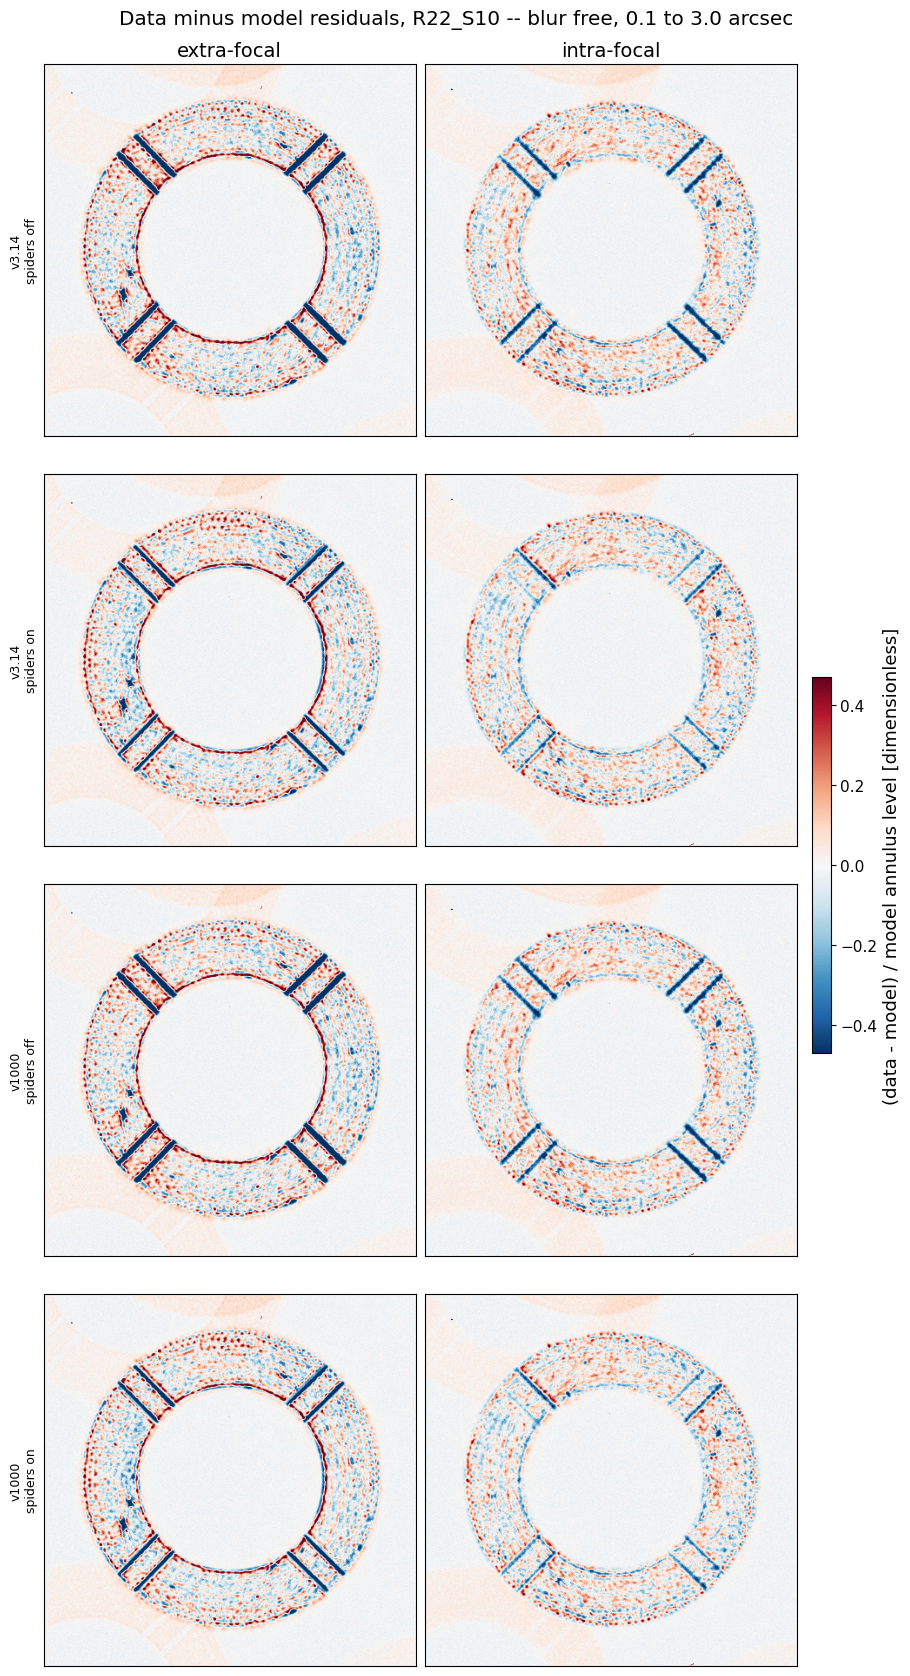

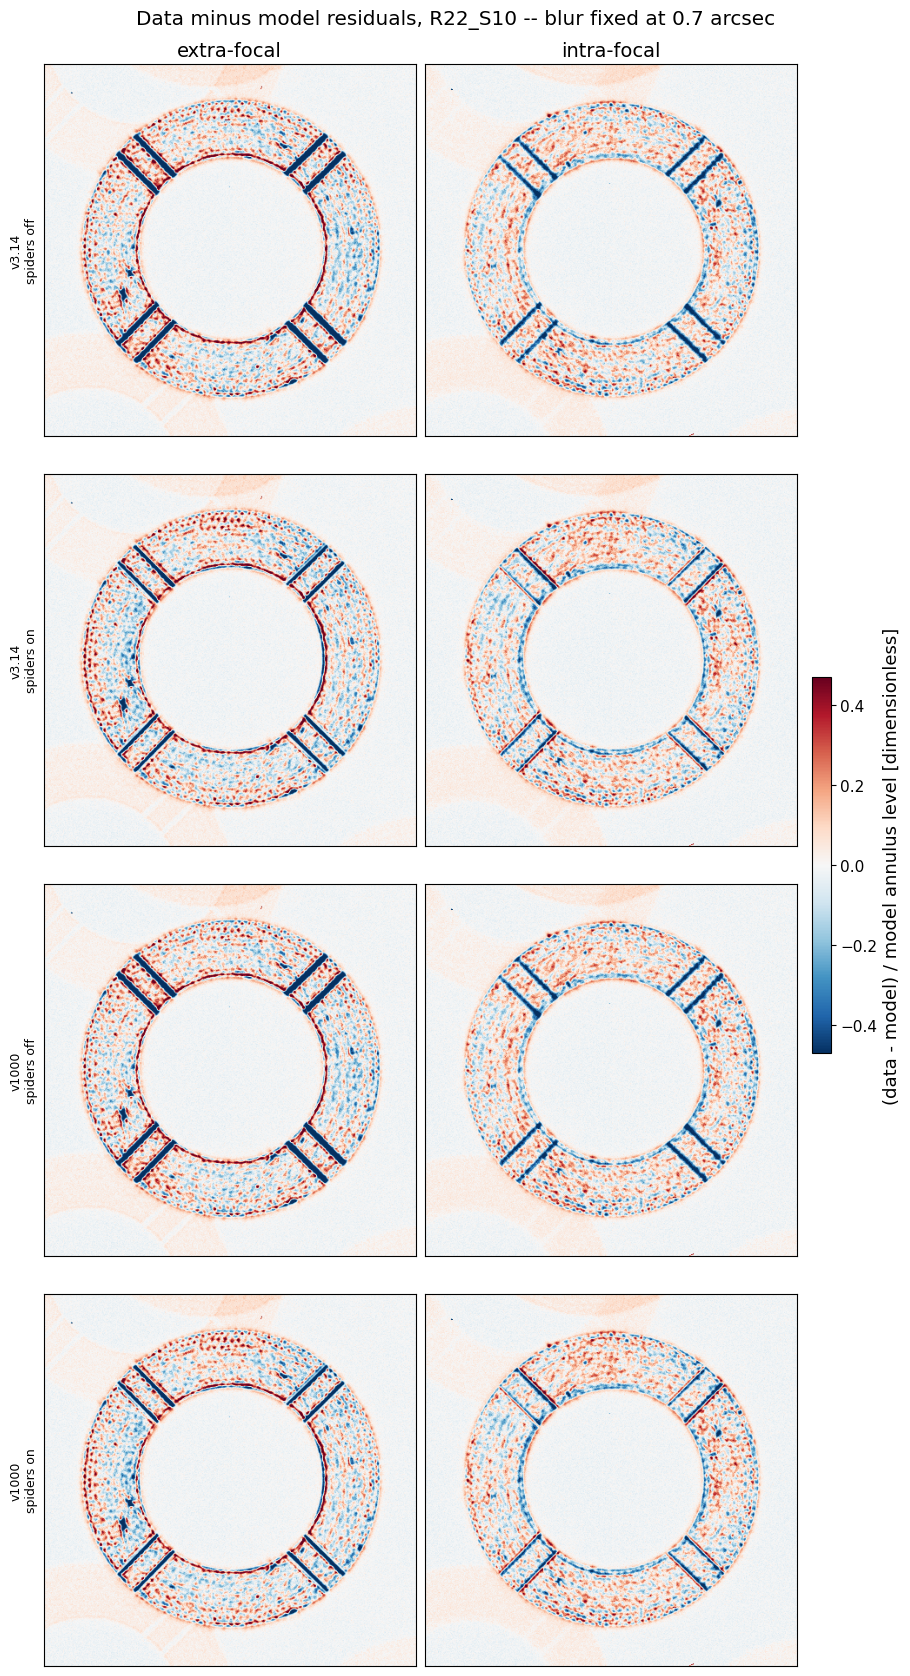

In [20]:
resid_images = {}
for key, f in fits.items():
    # Normalise by the model's annulus level so panels share one scale and the
    # residual reads as a fraction of the donut's own brightness.
    model = f["model_img"]
    scale = np.nanpercentile(model[model > 0], 75) if (model > 0).any() else 1.0
    resid_images[key] = (f["img"] - model) / scale

# One colour scale across both blur modes, so the two figures are comparable.
vlim = np.nanpercentile(np.abs(np.concatenate(
    [r.ravel() for r in resid_images.values()])), 99.0)
print(f"colour scale +/-{vlim:.3f} (dimensionless, fraction of the model's "
      f"annulus level)")
print("set to the 99th percentile of |residual| over all sixteen panels")

for blur in BLUR_MODES:
    tag = (f"blur free, 0.1 to {fwhm_max_arcsec} arcsec" if blur == "free"
           else f"blur fixed at {fwhm_fixed_arcsec} arcsec")
    fig, axes = plt.subplots(len(FIT_CONFIGS), 2,
                             figsize=(9.0, 4.2 * len(FIT_CONFIGS)))
    for row, (model_name, spiders) in enumerate(FIT_CONFIGS):
        for col, side in enumerate(("extra", "intra")):
            ax = axes[row, col]
            im = ax.imshow(resid_images[(model_name, spiders, blur, side)],
                           origin="lower", cmap="RdBu_r", vmin=-vlim, vmax=+vlim)
            ax.set_xticks([])
            ax.set_yticks([])
            if row == 0:
                ax.set_title(f"{side}-focal")
            if col == 0:
                ax.set_ylabel(
                    f"{model_name}\nspiders {'on' if spiders else 'off'}",
                    fontsize=9)

    fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02,
                 label="(data - model) / model annulus level [dimensionless]")
    fig.suptitle(f"Data minus model residuals, {detector_name} -- {tag}")
    fig.savefig(f"{output_dir}/residual_images_{blur}blur_{detector_name}.pdf",
                bbox_inches="tight")


In [21]:
# Where does the residual live? Split it by pupil zone, so the images above get
# a number. Signed mean shows a systematic push; nMAD shows unmodelled structure
# that averages out.
print(f"{'model':7s} {'spiders':8s} {'blur':>6s} {'side':>6s} {'zone':>12s} "
      f"{'signed mean':>12s} {'nMAD':>9s}")
for blur in BLUR_MODES:
    for model_name, spiders in FIT_CONFIGS:
        for side in ("extra", "intra"):
            key = (model_name, spiders, blur, side)
            resid = resid_images[key]
            ny, nx = resid.shape
            yy, xx = np.mgrid[0:ny, 0:nx]
            x0, y0 = rp.donut_centroid(fits[key]["model_img"])
            r = np.hypot(xx - x0, yy - y0) / fit_radial[key]["r_edge_pix"]
            for label, (lo, hi) in (("inner 0.62-0.70", (0.62, 0.70)),
                                    ("flat 0.70-0.94", (0.70, 0.94)),
                                    ("outer 0.94-1.00", (0.94, 1.00))):
                sel = np.isfinite(resid) & (r >= lo) & (r < hi)
                if not sel.any():
                    continue
                v = resid[sel]
                nmad = 1.48 * np.median(np.abs(v - np.median(v)))
                print(f"{model_name:7s} {'on' if spiders else 'off':8s} "
                      f"{blur:>6s} {side:>6s} {label:>12s} "
                      f"{np.mean(v):>+12.4f} {nmad:>9.4f}")
    print()
print("Both dimensionless, as a fraction of the model's annulus level.")


model   spiders    blur   side         zone  signed mean      nMAD
v3.14   off        free  extra inner 0.62-0.70      +0.0471    0.1980
v3.14   off        free  extra flat 0.70-0.94      -0.0350    0.1285
v3.14   off        free  extra outer 0.94-1.00      -0.0029    0.1722
v3.14   off        free  intra inner 0.62-0.70      -0.0294    0.1409
v3.14   off        free  intra flat 0.70-0.94      -0.0034    0.1150
v3.14   off        free  intra outer 0.94-1.00      +0.0017    0.1504
v3.14   on         free  extra inner 0.62-0.70      +0.0397    0.1966
v3.14   on         free  extra flat 0.70-0.94      -0.0318    0.1214
v3.14   on         free  extra outer 0.94-1.00      +0.0060    0.1719
v3.14   on         free  intra inner 0.62-0.70      -0.0241    0.1310
v3.14   on         free  intra flat 0.70-0.94      -0.0045    0.1121
v3.14   on         free  intra outer 0.94-1.00      +0.0119    0.1493
v1000   off        free  extra inner 0.62-0.70      +0.0407    0.1963
v1000   off        free  ex

<a id='interpretation'></a>
## Interpretation

**Measured on seq_num 337 (extra) and 340 (intra), R22_S10, field angle
(-0.263, -0.062) deg. Numbers below are this notebook's output.**

The donut diameters come out at 6.95 mm extra and 6.85 mm intra, against the
6.7 mm `wfs/` predicted for a 4 + 4 mm camera-plus-M2 split and 7.0 mm for
camera-only 8 mm. Both sit between the two predictions, nearer the camera-only
value, so the images do **not** cleanly discriminate the split on size alone --
the Trim remains the evidence for 4 + 4 mm. The bounding-box diameter is also an
overestimate of the illuminated outer edge, which the profile puts at 341.5 and
335.7 pixel, i.e. 6.83 and 6.71 mm across.

Josh's ring is present and it is extra-focal, with the flux balance reversing
between the two sides:

| zone (normalised radius) | extra | intra | extra - intra |
|---|---|---|---|
| inner ring, 0.62-0.70 | 1.0073 | 0.8532 | **+0.1541** |
| outer, 0.94-1.00 | 0.8803 | 0.9760 | **-0.0957** |

All dimensionless normalised flux, relative to the mean over the illuminated
annulus. The intra-minus-extra difference peaks at **-0.3330 (dimensionless) at
normalised radius 0.648**, just outside the inner pupil edge (0.612 in v3.14,
0.620 in v1000), and not at the rim.

**This favours an OPD term over a pupil-model error.** Flux moves toward the inner
edge extra-focally and toward the outer edge intra-focally, with the two zones
opposite in sign and comparable in size, so the total is conserved and
redistributed radially. A mask boundary error would move an edge *position* the
same way on both sides of focus rather than swapping the flux balance between
zones. The feature's location at the inner edge is consistent with a turned-down
edge on the inside of M1, which is where v1000 also moves the inner radius
(2.558 m to 2.5840 m, outward by 26.0 mm).

`ring_excess` is instructive about which pupil model fits the inner edge better.
Referenced to v1000's 0.6204 inner edge the extra-focal ring reads **+0.0132**;
referenced to v3.14's 0.6120 it reads **-0.0626**, i.e. the band lands partly in
the central hole. That is independent support for v1000's inner radius, from the
images rather than from a fit.

**Caveats, before this is taken as settled.**

- One donut per side, on one sensor, on one night. The item asks for a
  distribution; this is a single pair.
- The profile is azimuthally averaged, so a localised figure error would be
  diluted and an azimuthal analysis is the obvious next cut.
- The two donuts differ in outer edge by 5.8 pixel (0.06 mm), which the
  normalisation removes by construction; whether that size difference is itself
  part of the effect has not been separated.
- Converting the normalised-flux ring above into um of wavefront, so it can be
  compared directly against the 0.21 to 0.25 um of Z11 split the best fit leaves
  unexplained (0.3119 to 0.3515 um measured less about 0.10 um from
  diffraction), is still to do.

## What the fits add

The 2x2 of pupil model against spider modelling separates two effects that turn
out to be **orthogonal**:

| | effect on Z11 split | effect on chi2/dof |
|---|---|---|
| pupil model, v3.14 to v1000 | +0.8043 to +0.3618 um wf, a 55 per cent cut | negligible |
| spiders, off to on | about -0.02 um wf | -19 per cent extra, -16 per cent intra |

So v1000 is the better pupil *geometry* for the Z11 diagnostic, and spiders are a
real image-fidelity gain that does not confound it. Step 6 of item 7 is answered:
spiders can be included with good fidelity, as a plain config toggle.

**The residual is not removed by any of them.** v1000 with spiders still leaves
+0.3515 um of wavefront with free blur and +0.3119 um with the blur fixed at the
measured seeing, against about 0.10 um from diffraction, and the radial
residual panels show the data-minus-model trace is largest near the inner edge in
every configuration. That is the same place the intra-minus-extra difference
peaks, and it is consistent with a residual OPD term rather than a mask error.

At the resolved 0.25 deg binning the azimuthal structure is much larger than it
looked at 5 deg: peak-to-peak is 1.0150 extra-focal against 0.5711 intra-focal,
against 0.4392 and 0.2632 at 5 deg per bin. The intra-minus-extra difference
peaks at +0.5920 at 140.4 deg against a robust scatter of 0.0543 (all
dimensionless). The extra-focal donut is substantially more azimuthally
structured than the intra one. Localising that to a sector of M1 needs more than
one donut pair.

## The residual images

The 2-D residuals make the sign flip a direct measurement rather than an
inference from two projections, and it is **identical in all four
configurations**:

| zone | extra, signed mean | intra, signed mean |
|---|---|---|
| inner 0.62-0.70 | +0.033 to +0.047 | -0.030 to -0.035 |
| flat 0.70-0.94 | -0.032 to -0.035 | -0.003 to -0.001 |
| outer 0.94-1.00 | -0.006 to +0.009 | -0.002 to +0.009 |

Dimensionless, as a fraction of the model's annulus level, ranges over the four
configurations. The inner zone is positive extra-focally and negative
intra-focally in every case, with the flat zone taking the compensating deficit
on the extra side. Neither the pupil model nor the spiders shifts this, which is
what makes it a residual OPD term and not a mask-geometry error.

The nMAD columns also show the residual is **largest in the inner and outer
zones and smallest in the flat middle** (about 0.20 and 0.17 against 0.13
extra-focally), so the forward model fails hardest at both pupil boundaries.

Fixing the blur at 0.7 arcsec **sharpens the intra-focal inner-zone deficit** from
-0.029 to -0.062 (dimensionless) while leaving the extra-focal excess near
+0.033, so the sign flip is not only preserved but more pronounced once the blur
can no longer hide it.

## Fitted Zernikes, and a basis bug that was corrupting Z4

An earlier version of this notebook reported a v1000 Z4 split of **+4.1147 um
wf** against v3.14's -0.2176 um wf, and called it a pupil-scale/defocus
degeneracy. That was a **bug**, not physics.

`batoid.zernikeTA` was being called with `eps=telescope.pupilObscuration`, which
both YAML models carry as the *nominal* 0.612, while danish received
`R_inner/R_outer = 0.6204` from v1000's traced mask. So under v1000 the reference
wavefront and the fitted deviation were expressed on **different annular Zernike
bases**. Z4 is the term most sensitive to annulus width and absorbed the whole
mismatch. Under v3.14 the two bases agree exactly, which is why only v1000 looked
wrong.

Taking `eps` from `Instrument.obscuration`, so both sides use one basis, collapses
the v1000 Z4 split to **+0.0205 um wf**. Z11 moves by 0.005 um wf, from +0.3669
to +0.3618 um wf, so **every Z11 conclusion below is unaffected** -- which is
itself the reason Z11 and not Z4 is the diagnostic this study rests on.

Z4 is still not a measurement of the telescope's defocus: the fits are unpaired
and single-sided, so Z4 trades against flux, centroid and blur. It is reported as
a consistency check on the pupil basis.

**Z22 (secondary spherical) splits far less than Z11, and the pupil model helps
it too:** -0.0737 um wf of split under v3.14 against -0.0137 um wf under v1000
(spiders off, free blur). Its split is the opposite sign to Z11's and about 5 to
20 times smaller, so whatever drives the Z11 split is not a general
spherical-family mismatch.

## The blur: relaxing the bound, and fixing it at the DIMM seeing

With the ceiling raised from 1.5 to 3.0 arcsec the intra-focal fits came off the
bound but **stayed high**: 1.509 to 1.662 arcsec against 0.984 to 1.018 arcsec
extra-focally. So the 1.5 arcsec pinning was not the cause of the asymmetry, it
was a symptom. The intra-focal donut genuinely prefers roughly 60 per cent more
blur than the extra-focal one, in every pupil configuration.

That is nearly twice the measured seeing. The DIMM read 0.65 to 0.80 arcsec on
these visits and nearby in-focus acquisition images had about 0.9 arcsec of blur,
so the second set of fits holds the blur at **0.7 arcsec** and lets the Zernikes
absorb what the blur no longer can.

| | free blur | fixed 0.7 arcsec |
| --- | --- | --- |
| chi2/dof extra (v1000, spiders on) | 11.822 | 12.077 |
| chi2/dof intra (v1000, spiders on) | 5.984 | 7.764 |
| Z11 split, v1000 spiders on [um wf] | +0.3515 | +0.3119 |
| Z11 split, v3.14 spiders off [um wf] | +0.8043 | +0.7782 |

**Fixing the blur costs the intra side much more than the extra side** --
`chi2/dof` rises 30 per cent intra-focally against 2 per cent extra-focally.
The excess blur the intra fit wants is therefore real unmodelled structure on
that side, not a fitting artifact, and it is not something the Zernikes through
Z26 can represent.

**The Z11 split is robust to the blur treatment.** It moves by 0.026 to 0.040 um
wf between free and fixed blur, against the 0.25 um wf that remains unexplained.
So the split is not an artifact of blur absorbing wavefront error.

## Spider depth: the modelled vanes are about half as deep as the data's

Measured as the deepest azimuthal dip below the profile median (dimensionless):

| | extra-focal | intra-focal |
| --- | --- | --- |
| data | **0.7648** | **0.4612** |
| model, spiders on, free blur | 0.3439 to 0.3545 | 0.3051 to 0.3107 |
| model, spiders on, fixed 0.7 arcsec | 0.3609 to 0.3710 | 0.3872 to 0.4055 |
| model, spiders off | 0.0433 to 0.0883 | 0.0740 to 0.0743 |

Switching spiders on recovers most of the vane depth -- from about 0.05 to about
0.35 -- so the shadow is modelled in roughly the right place and with roughly the
right strength. But it is **not deep enough**: extra-focally the data reach
0.7648 against the model's best 0.3710, a factor of about 2.1. Fixing the blur
closes part of the gap (the free-blur fits were using blur to smear the vanes),
and on the **intra** side fixed blur gets within 12 per cent (0.4055 against
0.4612). Extra-focally a large deficit remains.

So the answer to "is the spider depth correctly modelled" is **partly**: the
intra-focal vanes are nearly right once the blur is held at the measured seeing,
and the extra-focal vanes are about half as deep as they should be. The vanes are
also the one feature where the free-blur fit was clearly cheating.

**The intra/extra blur asymmetry survives every pupil model and the relaxed
bound, and remains unexplained.** See the blur section above: it is 1.51 to
1.66 arcsec intra against 0.98 to 1.02 arcsec extra with a 3.0 arcsec ceiling,
and forcing both to the measured 0.7 arcsec costs the intra side 30 per cent in
`chi2/dof` against 2 per cent extra.
